<h1> Emmanuel M. Aviles - MIDTERM HANDS ON EXAM</h1>
<h1>BSIT-3B</h1>

<h1>Imports</h1>

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import folium
from folium.plugins import HeatMap

<h1> Dataframe</h1>

In [2]:
df = pd.read_csv('chicago_2001_presents.csv')
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13311263,JG503434,07/29/2022 03:39:00 AM,023XX S TROY ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,RESIDENCE,True,False,...,25.0,30.0,17,NaN,NaN,2022,04/18/2024 03:40:59 PM,NaN,NaN,NaN
1,13053066,JG103252,01/03/2023 04:44:00 PM,039XX W WASHINGTON BLVD,2017,NARCOTICS,MANUFACTURE / DELIVER - CRACK,SIDEWALK,True,False,...,28.0,26.0,18,NaN,NaN,2023,01/20/2024 03:41:12 PM,NaN,NaN,NaN
2,12131221,JD327000,08/10/2020 09:45:00 AM,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,1.0,24.0,03,1162795.0,1909900.0,2020,05/17/2025 03:40:52 PM,41.908418,-87.677407,"(41.908417822, -87.67740693)"
3,11227634,JB147599,08/26/2017 10:00:00 AM,001XX W RANDOLPH ST,0281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL/MOTEL,False,False,...,42.0,32.0,02,NaN,NaN,2017,02/11/2018 03:57:41 PM,NaN,NaN,NaN
4,13203321,JG415333,09/06/2023 05:00:00 PM,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,42.0,32.0,14,1174694.0,1901831.0,2023,11/04/2023 03:40:18 PM,41.886018,-87.633938,"(41.886018055, -87.633937881)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8410193,13973682,JJ422722,09/20/2025 09:30:00 PM,060XX N ARTESIAN AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,40.0,2.0,07,1158892.0,1940132.0,2025,09/28/2025 03:42:59 PM,41.991457,-87.690912,"(41.99145724, -87.690912186)"
8410194,13973492,JJ422488,09/20/2025 11:30:00 PM,004XX N PEORIA ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,27.0,24.0,07,1170336.0,1902935.0,2025,09/28/2025 03:42:59 PM,41.889144,-87.649909,"(41.889143855, -87.649909004)"
8410195,13973306,JJ422245,09/20/2025 07:08:00 PM,107XX S PRAIRIE AVE,0560,ASSAULT,SIMPLE,APARTMENT,True,True,...,9.0,49.0,08A,1179819.0,1833810.0,2025,09/28/2025 03:42:59 PM,41.699246,-87.617199,"(41.699245987, -87.61719874)"
8410196,13973002,JJ422001,09/20/2025 03:55:00 PM,034XX W 63RD ST,2024,NARCOTICS,POSSESS - HEROIN (WHITE),POLICE FACILITY / VEHICLE PARKING LOT,True,False,...,14.0,66.0,18,1154582.0,1862632.0,2025,09/28/2025 03:42:59 PM,41.778877,-87.708840,"(41.778877155, -87.708840106)"


<h1> Cleaning the Data</h1>

In [3]:
df['Date'] = df['Date'].astype(str)
df['Date'] = df['Date'].apply(lambda x: x.replace('/', '-') if pd.notnull(x) else x)
df['Date'] = df['Date'].apply(lambda x: x.strip() if pd.notnull(x) else x)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].mode()[0])
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].mode()[0])

df['X'] = df['Longitude']
df['Y'] = df['Latitude']

df['Location'] = df.apply(lambda row: f"({row['Y']}, {row['X']})", axis=1)

df['District'] = df['District'].fillna(-1).astype(int)
df['Location Description'] = df['Location Description'].fillna('unaccounted_location')
df['FBI Code'] = df['FBI Code'].fillna('unknown_fbi_code')
df['Ward'] = df['Ward'].fillna(-1).astype(int)
df['Community Area'] = df['Community Area'].fillna(-1).astype(int)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Hour'] = df['Date'].dt.hour

print(df.isnull().sum())
print(df.dtypes)

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description        0
Arrest                      0
Domestic                    0
Beat                        0
District                    0
Ward                        0
Community Area              0
FBI Code                    0
X Coordinate            93685
Y Coordinate            93685
Year                        0
Updated On                  0
Latitude                    0
Longitude                   0
Location                    0
X                           0
Y                           0
Month                       0
Day                         0
DayOfWeek                   0
Hour                        0
dtype: int64
ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                         

In [4]:
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Updated On,Latitude,Longitude,Location,X,Y,Month,Day,DayOfWeek,Hour
0,13311263,JG503434,2022-07-29 03:39:00,023XX S TROY ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,RESIDENCE,True,False,...,04/18/2024 03:40:59 PM,41.976290,-87.905227,"(41.976290414, -87.905227221)",-87.905227,41.976290,7,29,4,3
1,13053066,JG103252,2023-01-03 16:44:00,039XX W WASHINGTON BLVD,2017,NARCOTICS,MANUFACTURE / DELIVER - CRACK,SIDEWALK,True,False,...,01/20/2024 03:41:12 PM,41.976290,-87.905227,"(41.976290414, -87.905227221)",-87.905227,41.976290,1,3,1,16
2,12131221,JD327000,2020-08-10 09:45:00,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,05/17/2025 03:40:52 PM,41.908418,-87.677407,"(41.908417822, -87.67740693)",-87.677407,41.908418,8,10,0,9
3,11227634,JB147599,2017-08-26 10:00:00,001XX W RANDOLPH ST,0281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL/MOTEL,False,False,...,02/11/2018 03:57:41 PM,41.976290,-87.905227,"(41.976290414, -87.905227221)",-87.905227,41.976290,8,26,5,10
4,13203321,JG415333,2023-09-06 17:00:00,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,11/04/2023 03:40:18 PM,41.886018,-87.633938,"(41.886018055, -87.633937881)",-87.633938,41.886018,9,6,2,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8410193,13973682,JJ422722,2025-09-20 21:30:00,060XX N ARTESIAN AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,09/28/2025 03:42:59 PM,41.991457,-87.690912,"(41.99145724, -87.690912186)",-87.690912,41.991457,9,20,5,21
8410194,13973492,JJ422488,2025-09-20 23:30:00,004XX N PEORIA ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,09/28/2025 03:42:59 PM,41.889144,-87.649909,"(41.889143855, -87.649909004)",-87.649909,41.889144,9,20,5,23
8410195,13973306,JJ422245,2025-09-20 19:08:00,107XX S PRAIRIE AVE,0560,ASSAULT,SIMPLE,APARTMENT,True,True,...,09/28/2025 03:42:59 PM,41.699246,-87.617199,"(41.699245987, -87.61719874)",-87.617199,41.699246,9,20,5,19
8410196,13973002,JJ422001,2025-09-20 15:55:00,034XX W 63RD ST,2024,NARCOTICS,POSSESS - HEROIN (WHITE),POLICE FACILITY / VEHICLE PARKING LOT,True,False,...,09/28/2025 03:42:59 PM,41.778877,-87.708840,"(41.778877155, -87.708840106)",-87.708840,41.778877,9,20,5,15


<h1>Checking Info</h1>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8410198 entries, 0 to 8410197
Data columns (total 28 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Case Number           object        
 2   Date                  datetime64[ns]
 3   Block                 object        
 4   IUCR                  object        
 5   Primary Type          object        
 6   Description           object        
 7   Location Description  object        
 8   Arrest                bool          
 9   Domestic              bool          
 10  Beat                  int64         
 11  District              int64         
 12  Ward                  int64         
 13  Community Area        int64         
 14  FBI Code              object        
 15  X Coordinate          float64       
 16  Y Coordinate          float64       
 17  Year                  int32         
 18  Updated On            object        
 19  

In [6]:
df.dtypes

ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                           object
IUCR                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                            bool
Domestic                          bool
Beat                             int64
District                         int64
Ward                             int64
Community Area                   int64
FBI Code                        object
X Coordinate                   float64
Y Coordinate                   float64
Year                             int32
Updated On                      object
Latitude                       float64
Longitude                      float64
Location                        object
X                              float64
Y                              float64
Month                            int32
Day                      

In [7]:
print(df['Beat'].unique())

[1033 1122 1424  122  123 1023  533 1633  322  331  732  824  813  925
  922  632 1413  511  512  523 1622  631  411  923  724 1211  324 1621
  611  733  821 1031 1111 2521 2514 2522 1433  423 1124  531 1013  224
  825 2513  232 1431 1412 1421 1432 1712 1422  833 2512 2532 2524  621
  432 2533  831  822 1634 2515 2033 1511 1021 1632 1131  612 1713  815
  421 1731 2433 1512 2222 2022 1423  613  835  722 1235  133  914 1914
  412  731 2013  222 2423 1611 1533 1115  434 2534 1214 2032  132 1135
  823 1523  215 2024 2234 1225 2031 1623  712  313 1913  433 1524 1012
 1531  935 1133 1911 1915  734  524  522  124  211 2413 1134 1650  431
  221 1733 1821 1921 2221  634  414 2432  114 1112 1925 1832  834  832
 1922  422 2211 2223  915  624 1931 2525 1113 1833 1631 1121 1655  726
  934 2411 2431  614 1213  312 1414  225 1123 2011 1811 1711  932 1234
 1224 1724  532 1831  323 1814  214 1014  924 1834 1232  921  131  931
  424  413 1222 2012  231 2232 1011 2412  735 2424  713 1522 2212 1934
  623 

In [8]:
print(df['District'].unique())

[10 11 14  1  5 16  3  7  8  9  6  4 12 25  2 17 20 15 24 22 19 18 31 21
 -1]


In [9]:
print(df['Ward'].unique())

[25 28  1 42  4 10 30  6  5 14 23 20 12  8 26  9 39 16 36 17 22 37 31  7
  3 29 35 32 33 45 38 47 24 48 21 11 18 46 15 49 41 34 40 27 50 19 43 13
 44  2 -1]


In [10]:
print(df['Community Area'].unique())

[30 26 24 32 29 54 15 69 43 68 63 65 37 58 44 22 49 53 11 45 23 71 19 46
 27 50 38 66 25 40 21 14 52 10  3 17 56 48 16 77 18 73 61 31 35 33 39  1
 20  9 51 28  4 70 57 75 42 55 67  2 76  8 34  5  6 74 60  7 13 36 12 72
 62 41 47 59 64 -1  0]


In [11]:
print(df['Primary Type'].unique())

['OFFENSE INVOLVING CHILDREN' 'NARCOTICS' 'ROBBERY' 'CRIM SEXUAL ASSAULT'
 'CRIMINAL DAMAGE' 'THEFT' 'BURGLARY' 'SEX OFFENSE' 'MOTOR VEHICLE THEFT'
 'BATTERY' 'HOMICIDE' 'CRIMINAL SEXUAL ASSAULT' 'OTHER OFFENSE'
 'WEAPONS VIOLATION' 'DECEPTIVE PRACTICE' 'STALKING' 'CRIMINAL TRESPASS'
 'ASSAULT' 'PROSTITUTION' 'KIDNAPPING' 'ARSON'
 'CONCEALED CARRY LICENSE VIOLATION' 'INTERFERENCE WITH PUBLIC OFFICER'
 'PUBLIC PEACE VIOLATION' 'LIQUOR LAW VIOLATION' 'INTIMIDATION'
 'HUMAN TRAFFICKING' 'GAMBLING' 'OBSCENITY' 'OTHER NARCOTIC VIOLATION'
 'NON-CRIMINAL' 'PUBLIC INDECENCY' 'RITUALISM' 'DOMESTIC VIOLENCE']


<h1> QUESTIONS AND 35 INSIGHTS, VISUALIZATIONS</h1>

<h2>1. How did the number of crimes change over the decades?</h2>

<h2>VISUALIZATION #1</h2>

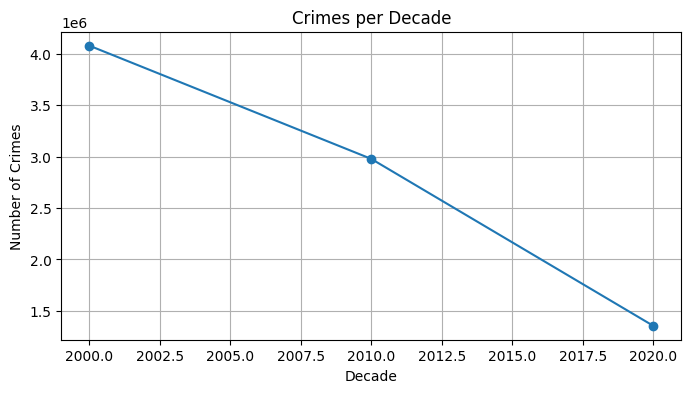

   Number of Crimes    count
0              2000  4077377
1              2010  2977239
2              2020  1355582


In [12]:
df['Decade'] = (df['Year'] // 10) * 10  
decade_counts = df['Decade'].value_counts().sort_index()

decade_counts.plot(kind='line', marker='o', figsize=(8,4), title="Crimes per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Crimes")
plt.grid(True)
plt.show()

df['Decade'] = (df['Year'] // 10) * 10  
decade_counts = df['Decade'].value_counts().sort_index()

print(decade_counts.reset_index().rename(columns={'index':'Decade', 'Decade':'Number of Crimes'}))

<h2>Insights: According to the result there is a steep decline of crimes from 2000 to 2020, likely reflecting a combination of improved policing, societal changes, and possibly pandemic-related effects in 2020. this also means it is good for the society because it is less crime.</h2>

<h1>2. Which crime types increased the most per decade?</h1>

<h2>VISUALIZATION #2</h2>

Top 10 Crime Types with Highest Increase per Decade:
 Decade                             Increase
Primary Type                               
WEAPONS VIOLATION                   10326.0
CRIMINAL SEXUAL ASSAULT              8276.0
CONCEALED CARRY LICENSE VIOLATION    1111.0
STALKING                              653.0
OBSCENITY                             141.0
HUMAN TRAFFICKING                      69.0
NON-CRIMINAL                           19.0
DOMESTIC VIOLENCE                      -1.0
PUBLIC INDECENCY                      -19.0
RITUALISM                             -22.0


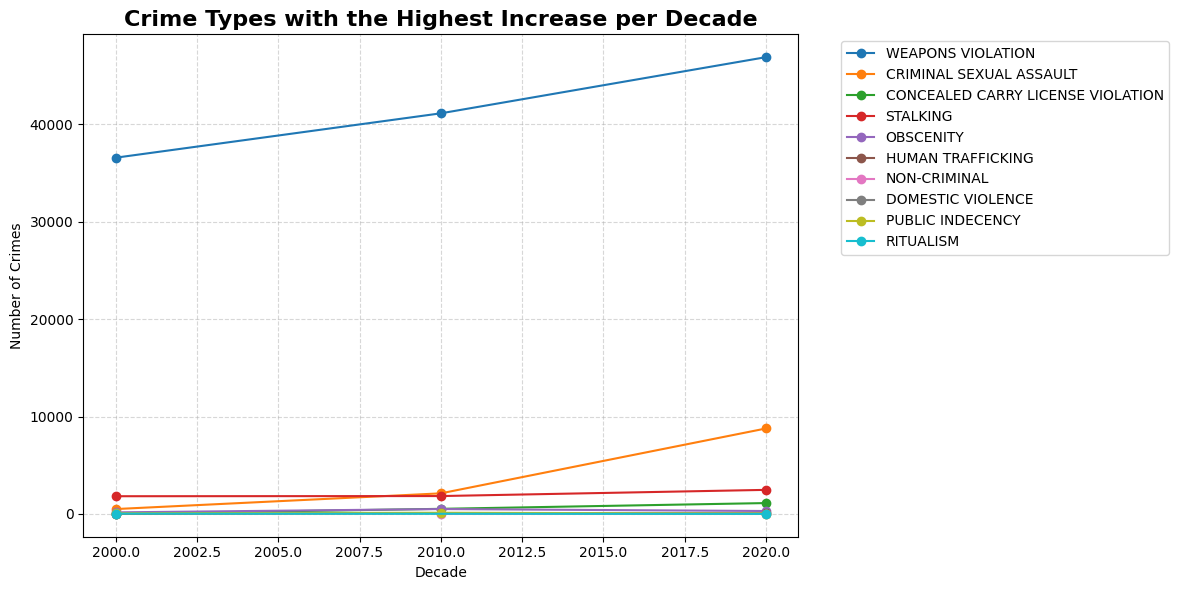

In [13]:
df['Decade'] = (df['Year'] // 10) * 10

crime_decade = df.groupby(['Decade', 'Primary Type']).size().reset_index(name='Count')
crime_pivot = crime_decade.pivot(index='Primary Type', columns='Decade', values='Count').fillna(0)
crime_pivot['Increase'] = crime_pivot[crime_pivot.columns.max()] - crime_pivot[crime_pivot.columns.min()]

top_increase = crime_pivot.sort_values('Increase', ascending=False).head(10)
print("Top 10 Crime Types with Highest Increase per Decade:\n", top_increase[['Increase']])

plt.figure(figsize=(12,6))
for crime in top_increase.index:
    subset = crime_decade[crime_decade['Primary Type']==crime]
    plt.plot(subset['Decade'], subset['Count'], marker='o', label=crime)

plt.title("Crime Types with the Highest Increase per Decade", fontsize=16, weight='bold')
plt.xlabel("Decade")
plt.ylabel("Number of Crimes")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Insights: It shows that weapon violation has the  largest increase (10,326 per decade), it means that weapon related crimes are getting caught more often than before or a rise in gun-related offenses. and also CONCEALED CARRY LICENSE VIOLATION also increased significantly, which may correlate with changes in firearm laws or enforcement intensity. Sexual and stalking crimes rising too.</h2>

<h2>3.Which hour of the day has the highest crime rate, and which has the lowest?</h2>

<h2>VISUALIZATION #3</h2>

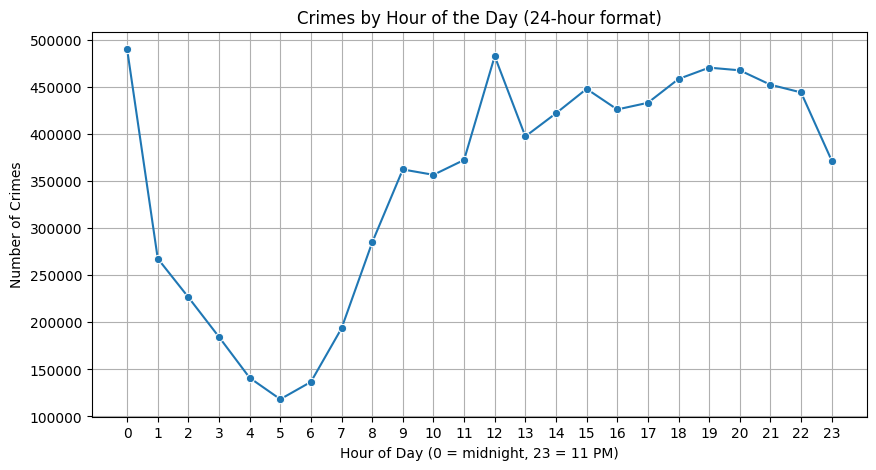

Hour
0     490142
1     267704
2     226631
3     184422
4     141052
5     118313
6     136726
7     193660
8     284850
9     362414
10    356706
11    372521
12    482714
13    397522
14    422062
15    447996
16    426156
17    433229
18    458515
19    470570
20    467734
21    452425
22    444246
23    371888
Name: count, dtype: int64


In [14]:
hour_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o')
plt.title("Crimes by Hour of the Day (24-hour format)")
plt.xlabel("Hour of Day (0 = midnight, 23 = 11 PM)")
plt.ylabel("Number of Crimes")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

print(hour_counts)

<h2>Insights: According to the result crime peaks around midnight (0:00), which is likely due to alcohol-related incidents, late-night street activity, and lower public supervision. And early morning has the lowest crime count around 5:00 AM, because it is when most people are at home and streets are less active.  </h2>

<h1>4. Do certain crime types dominate during peak hours?</h1>

<h2>VISUALIZATION #4</h2>

Primary Type
BATTERY                              497873
THEFT                                488882
CRIMINAL DAMAGE                      337337
NARCOTICS                            325767
ASSAULT                              171169
MOTOR VEHICLE THEFT                  159778
OTHER OFFENSE                        150754
ROBBERY                              110780
BURGLARY                             104782
CRIMINAL TRESPASS                     76240
DECEPTIVE PRACTICE                    57802
WEAPONS VIOLATION                     55337
PROSTITUTION                          35606
PUBLIC PEACE VIOLATION                20519
OFFENSE INVOLVING CHILDREN            15228
LIQUOR LAW VIOLATION                   8763
INTERFERENCE WITH PUBLIC OFFICER       8416
SEX OFFENSE                            8104
CRIM SEXUAL ASSAULT                    7627
GAMBLING                               7404
HOMICIDE                               4438
ARSON                                  4107
CRIMINAL SEXUAL ASS

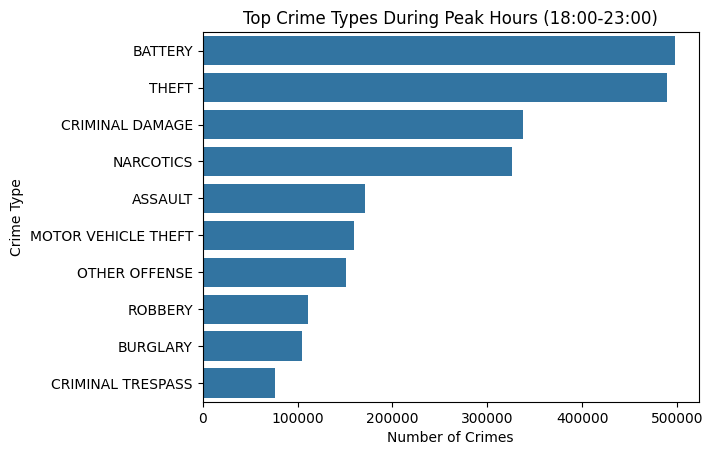

In [15]:
peak_hours = df[df['Hour'].between(18, 23)]

peak_counts = peak_hours['Primary Type'].value_counts()
print(peak_counts)

top_crimes = peak_counts.head(10)
sns.barplot(y=top_crimes.index, x=top_crimes.values)
plt.title("Top Crime Types During Peak Hours (18:00-23:00)")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.show()

<h2>Insights: According to the result violent crimes BATTERY (497,873) and ASSAULT (171,169) dominate the peaks hours. This means that interpersonal conflicts and physical confrontations are more likely happens during the time of high public activity, such as evenings and late nights. Because thats when teen likely to go out to hangout.</h2>

<h2>5. What crimes usually happen by hour through the year 2001 till present?</h2>

<h2>VISUALIZATION #5</h2>

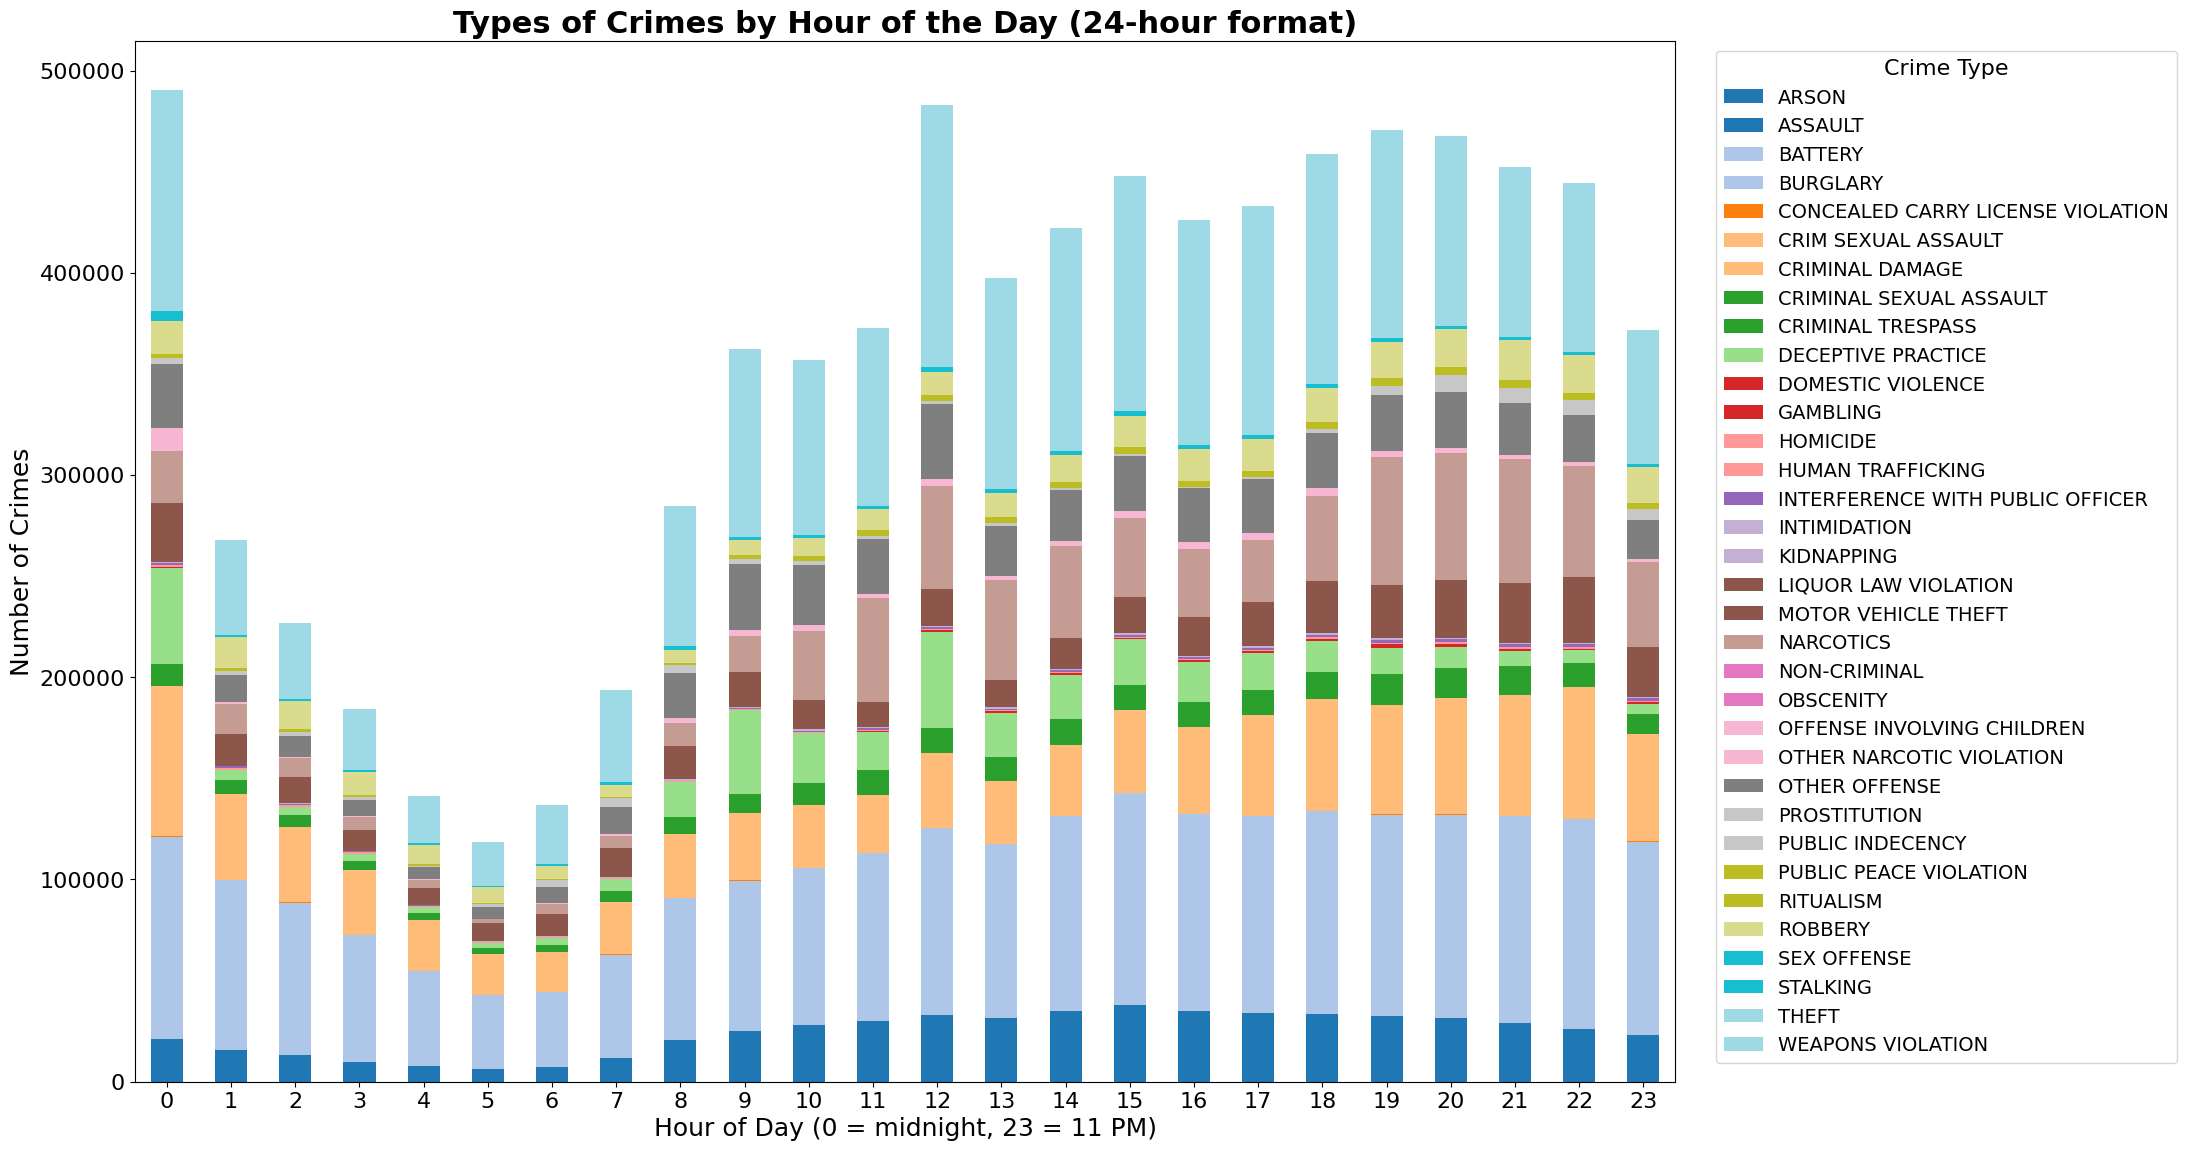

In [16]:
hourly_crimes = df.groupby(['Hour', 'Primary Type']).size().unstack(fill_value=0)

ax = hourly_crimes.plot(
    kind='bar',
    stacked=True,
    figsize=(22,12),
    colormap="tab20"
)

plt.title("Types of Crimes by Hour of the Day (24-hour format)", fontsize=22, weight='bold')
plt.xlabel("Hour of Day (0 = midnight, 23 = 11 PM)", fontsize=18)
plt.ylabel("Number of Crimes", fontsize=18)

plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=14,
    title_fontsize=16
)

plt.tight_layout()
plt.show()

<h2>Insights: It shows that in the graph that there are different types of crimes but in the result of this graph from the chicago crime theft and battery dominates these 2 are 1 violence and the other was a property related crime this type of crimes don't usually get broadcast in the media maybe because it is too common for them but it shows that here these 2 still active anytime 24/7.</h2>

<h1>6. Do some locations have specific hour-based crime patterns?</h1>
<h2>VISUALIZATION #6</h2>

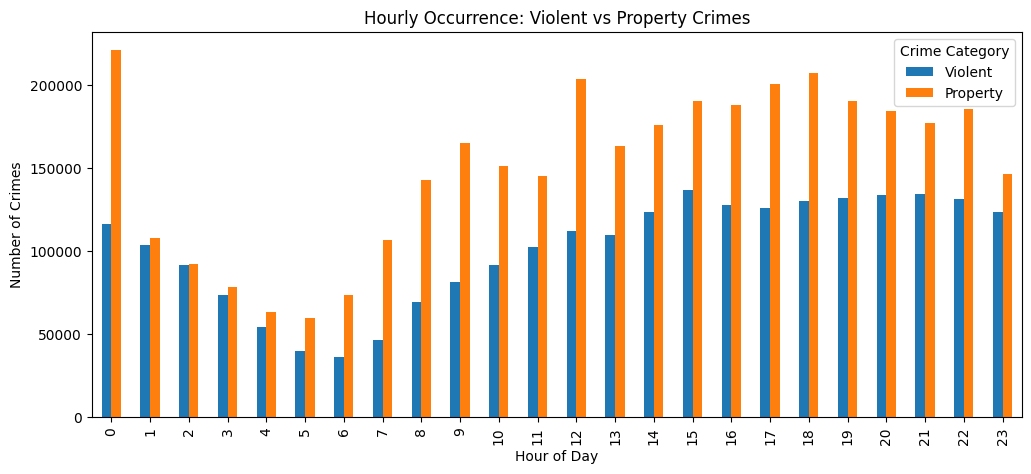

Peak hours for each category:
Crime Category
Violent     15
Property     0
dtype: int32


In [17]:
violent_crimes = ['HOMICIDE', 'ASSAULT', 'ROBBERY', 'BATTERY']
property_crimes = ['BURGLARY', 'THEFT', 'MOTOR VEHICLE THEFT', 'CRIMINAL DAMAGE']

df['Crime Category'] = df['Primary Type'].apply(lambda x: 'Violent' if x in violent_crimes else ('Property' if x in property_crimes else 'Other'))

hour_category_counts = df.groupby(['Hour', 'Crime Category']).size().unstack(fill_value=0)

hour_category_counts[['Violent','Property']].plot(kind='bar', figsize=(12,5))
plt.title("Hourly Occurrence: Violent vs Property Crimes")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.show()

peak_hours = hour_category_counts[['Violent','Property']].idxmax()
print("Peak hours for each category:")
print(peak_hours)

<h2>Insights: According to the data violent crimes peak in the afternoon 15:00. Crimes like HOMICIDE, ASSAULT, ROBBERY, and BATTERY reach their highest frequency around 3 PM. It means that violent offenses are more likely during daytime hours when people are active, possibly near schools, workplaces, or public areas.
 ------------------------------------------------------------------------------------------------------------------------------------------------------

Property crimes peak at midnight (0:00) crimes like BURGLARY, THEFT, MOTOR VEHICLE THEFT and CRIMINAL DAMAGE occur most often at midnight.
This means the idea that property crimes is to take advantage of midnight,empty streets and reduced supervision, such as burglaries or vehicle thefts in quiet night.</h2>

<h2>7. Which month records the highest number of “Offense Involving Children” cases?</h2>

<h2>VISUALIZATION #7</h2>

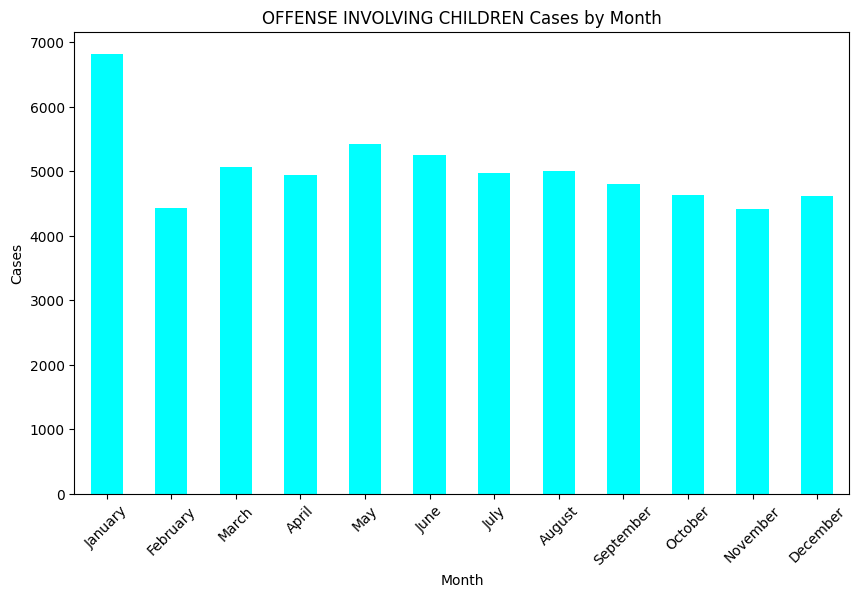

In [47]:
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

offense_children = df[df["Primary Type"] == "OFFENSE INVOLVING CHILDREN"]
monthly_counts = offense_children.groupby("Month").size()


monthly_counts.index = monthly_counts.index.map(month_names)

monthly_counts.plot(
    kind="bar",
    title="OFFENSE INVOLVING CHILDREN Cases by Month",
    xlabel="Month",
    ylabel="Cases",
    color="cyan",
    figsize=(10,6)
)
plt.xticks(rotation=45)
plt.show()


<h2>Insights: This bar plot shows the number of “Offense Involving Children” cases recorded each month. The data indicates that May has the highest number of cases, with approximately 175, while January has the lowest, with around 100 cases. This suggests that offenses involving children tend to occur more frequently in May.

<h2>8. Top Locations of theft crimes 2001 - 2010</h2>

<h2>VISUALIZATION #8</h2>

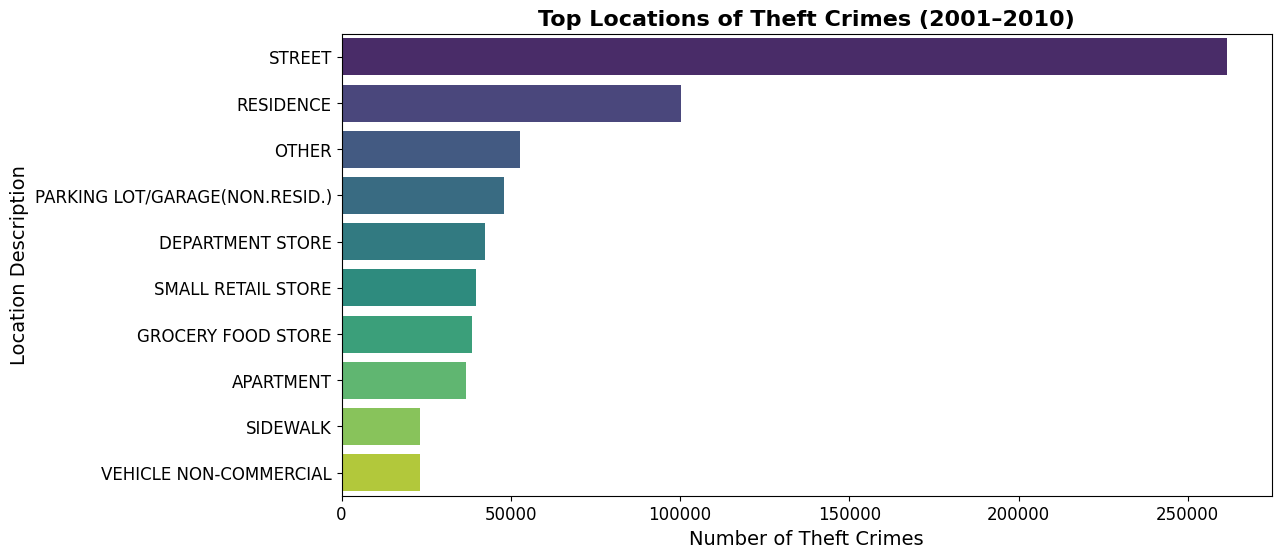

In [19]:
theft_2001_2010 = df[(df['Year'] >= 2001) & 
                     (df['Year'] <= 2010) & 
                     (df['Primary Type'] == 'THEFT')]

location_counts = theft_2001_2010['Location Description'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette="viridis")

plt.title("Top Locations of Theft Crimes (2001–2010)", fontsize=16, weight='bold')
plt.xlabel("Number of Theft Crimes", fontsize=14)
plt.ylabel("Location Description", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

<h2>Insights: According the data The top 1 location where theft usually happens was the street. Just like from the previous geo spatial I used theft covered the whole chicago. Well we can think of it that the street is the most hotspot for thieves because here they can observe peoples walking by with there jewelries or any expensive things.</h2>

<h2>9. Theft per year 2001-2010</h2>

<h2>VISUALIZATION #9</h2>

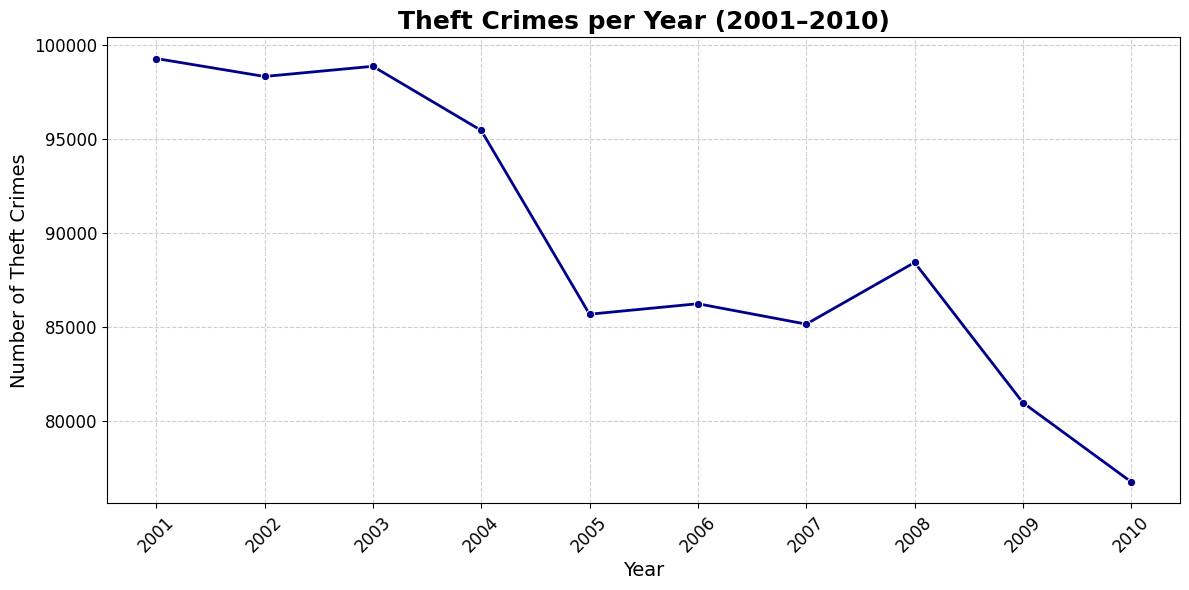

In [20]:
theft_2001_2010 = df[(df['Year'] >= 2001) & 
                     (df['Year'] <= 2010) & 
                     (df['Primary Type'] == 'THEFT')]

yearly_counts = theft_2001_2010.groupby('Year').size().reset_index(name='Count')

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_counts, 
             x='Year', 
             y='Count', 
             marker='o', 
             linewidth=2, 
             color='darkblue')

plt.title("Theft Crimes per Year (2001–2010)", fontsize=18, weight='bold')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Theft Crimes", fontsize=14)
plt.xticks(yearly_counts['Year'], rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<h2>Insights: According to the graphs theft crimes during 2001 to 2010 reach it peaks at 2001 maybe because cctv's are not much a thing at that time but here we can slowly see the decline of the theft during that time because this was the time technology takeovers maybe thieves got scared to steal anymore thats why it declined.  </h2>

<h2>10. Theft per month 2001-2010</h2>
<h2>VISUALIZATION #10</h2>

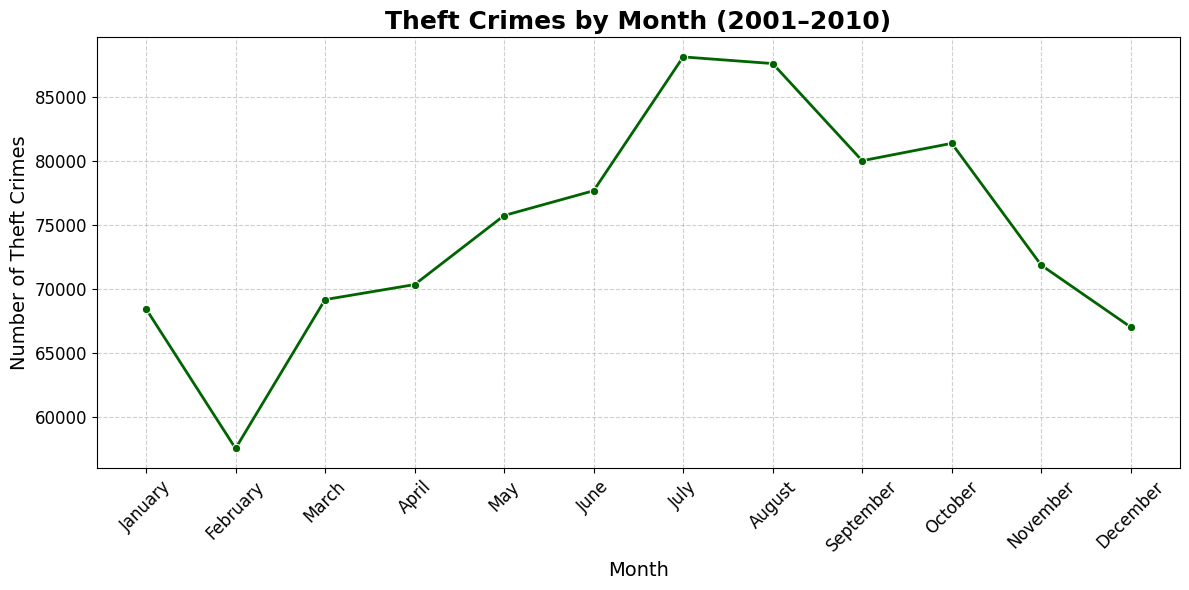

In [21]:
theft_2001_2010 = df[(df['Year'] >= 2001) & 
                     (df['Year'] <= 2010) & 
                     (df['Primary Type'] == 'THEFT')]

theft_2001_2010['Month'] = pd.to_datetime(theft_2001_2010['Date']).dt.month_name()

month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]

monthly_counts = theft_2001_2010.groupby('Month').size().reindex(month_order).reset_index(name='Count')

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_counts, 
             x='Month', 
             y='Count', 
             marker='o', 
             linewidth=2, 
             color='darkgreen')

plt.title("Theft Crimes by Month (2001–2010)", fontsize=18, weight='bold')
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Theft Crimes", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<h2>Insights: As from we can see in this data it has a mountain like theft crimes by month graph. This graph was not stable but there was february it has the lowest recorded theft crime according to this graph maybe there was an event every february that made it decrease every time during 2001 to 2010.</h2>

<h2>11. Theft per Week 2001- 2010</h2>
<h2>VISUALIZATION #11</h2>


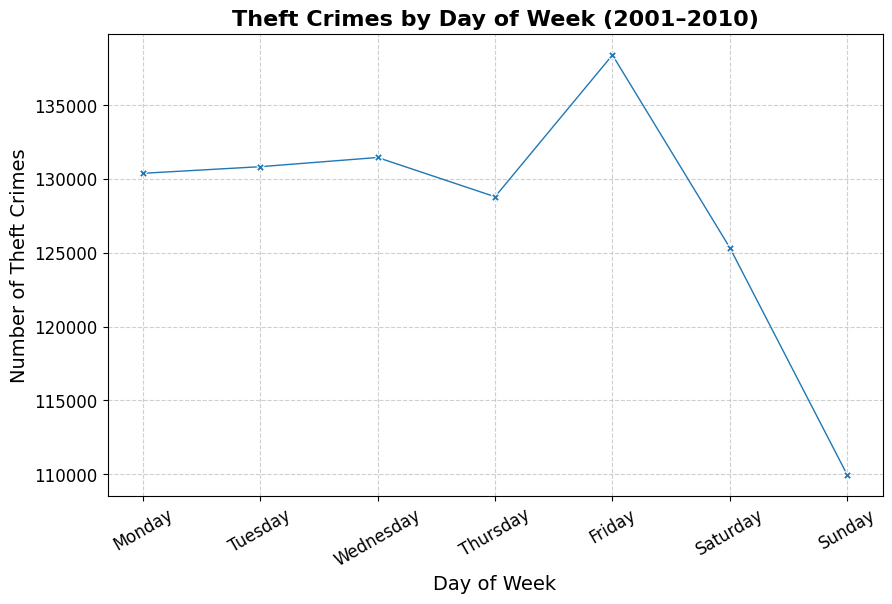

Day_of_Week
Monday       130395
Tuesday      130843
Wednesday    131467
Thursday     128806
Friday       138412
Saturday     125346
Sunday       109948
Name: count, dtype: int64


In [22]:
theft_2001_2010 = df[(df['Year'] >= 2001) & 
                     (df['Year'] <= 2010) & 
                     (df['Primary Type'] == 'THEFT')]

theft_2001_2010['Day_of_Week'] = pd.to_datetime(theft_2001_2010['Date']).dt.day_name()

weekday_counts = theft_2001_2010['Day_of_Week'].value_counts()
weekday_counts = weekday_counts.reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.figure(figsize=(10,6))
sns.lineplot(x=weekday_counts.index, y=weekday_counts.values, marker='X', linewidth=1)

plt.title("Theft Crimes by Day of Week (2001–2010)", fontsize=16, weight='bold')
plt.xlabel("Day of Week", fontsize=14)
plt.ylabel("Number of Theft Crimes", fontsize=14)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

theft_2001_2010 = df[(df['Year'] >= 2001) & 
                     (df['Year'] <= 2010) & 
                     (df['Primary Type'] == 'THEFT')]

theft_2001_2010['Day_of_Week'] = pd.to_datetime(theft_2001_2010['Date']).dt.day_name()

weekday_counts = theft_2001_2010['Day_of_Week'].value_counts()
weekday_counts = weekday_counts.reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
print(weekday_counts)

<h2>Insights: This data consist the theft crimes by day of week during the year 2001 to 2010 during monday to wednesday it has slight changes but when every friday it reaches the peak maybe because people in chicago like to party at friday night that's why thieves comes out. And when weekends came the line graph steeply decline it means there must be a event that make this happens. </h2>

<h2>12. Since 2001 where do most homicides usually happen based on the location description?</h2>
<h2>VISUALIZATION #12</h2>

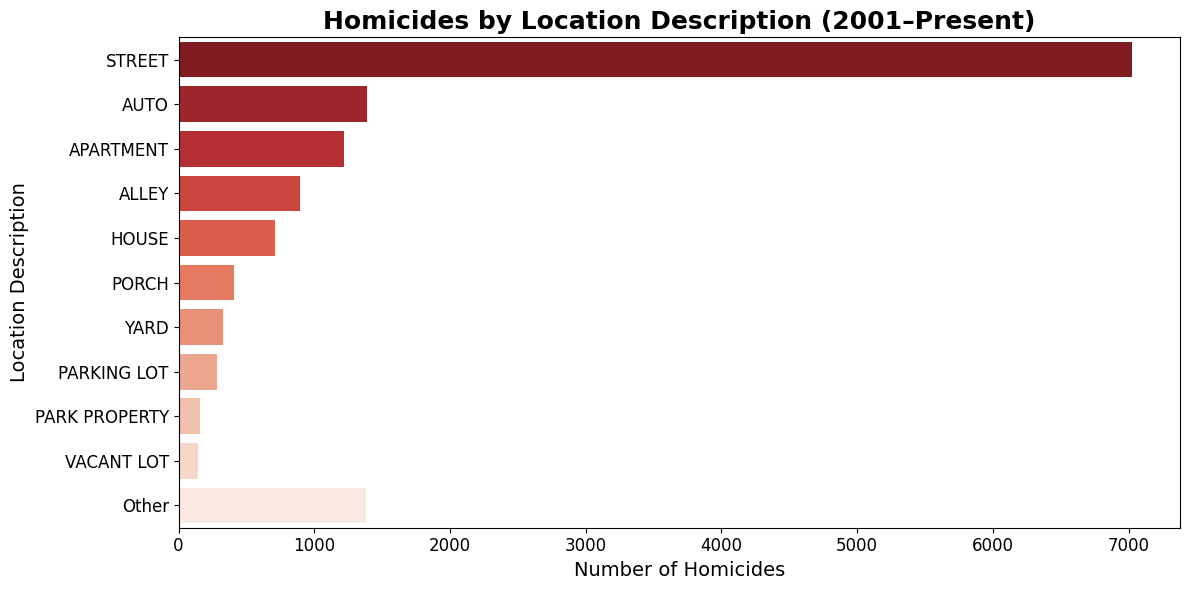

Location Description
STREET           7027
AUTO             1389
APARTMENT        1218
ALLEY             894
HOUSE             709
PORCH             407
YARD              331
PARKING LOT       286
PARK PROPERTY     161
VACANT LOT        144
Other            1383
Name: count, dtype: int64


In [23]:
homicides = df[(df['Year'] >= 2001) & 
               (df['Primary Type'] == 'HOMICIDE')]

location_counts = homicides['Location Description'].value_counts()

top_10 = location_counts.head(10)

other_count = location_counts[10:].sum()

top_10['Other'] = other_count

plt.figure(figsize=(12,6))
sns.barplot(x=top_10.values, y=top_10.index, palette='Reds_r')

plt.title("Homicides by Location Description (2001–Present)", fontsize=18, weight='bold')
plt.xlabel("Number of Homicides", fontsize=14)
plt.ylabel("Location Description", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

print(top_10)


<h2>Insights: According to the graph streets are the most common homicide locations. Street has a recorded data of 7,027 cases, largest on its own category. This means that most homicides occur in public, accessible areas rather than private spaces. Possible factors are gang activity, public disputes, robberies, and street-level violence.</h2>

<h2>13. Specific spot of the street homicides</h2>
<h2>VISUALIZATION #13</h2>

In [24]:
street_homicides = df[(df['Year'] >= 2001) &
                       (df['Primary Type'] == 'HOMICIDE') &
                       (df['Location Description'] == 'STREET')]

street_homicides = street_homicides.dropna(subset=['Latitude', 'Longitude'])

m = folium.Map(location=[street_homicides['Latitude'].mean(), 
                         street_homicides['Longitude'].mean()],
               zoom_start=11)

heat_data = street_homicides[['Latitude', 'Longitude']].values.tolist()

HeatMap(heat_data, radius=10).add_to(m)

m


<h2>Insights: According to this geo spatial map every corner of chicago has a homicide case but from this data humboldt park has the most case than the the other areas from 2001 to present.</h2>

<h2>14. Date time and location desription of crime</h2>
<h2>VISUALIZATION #14</h2>

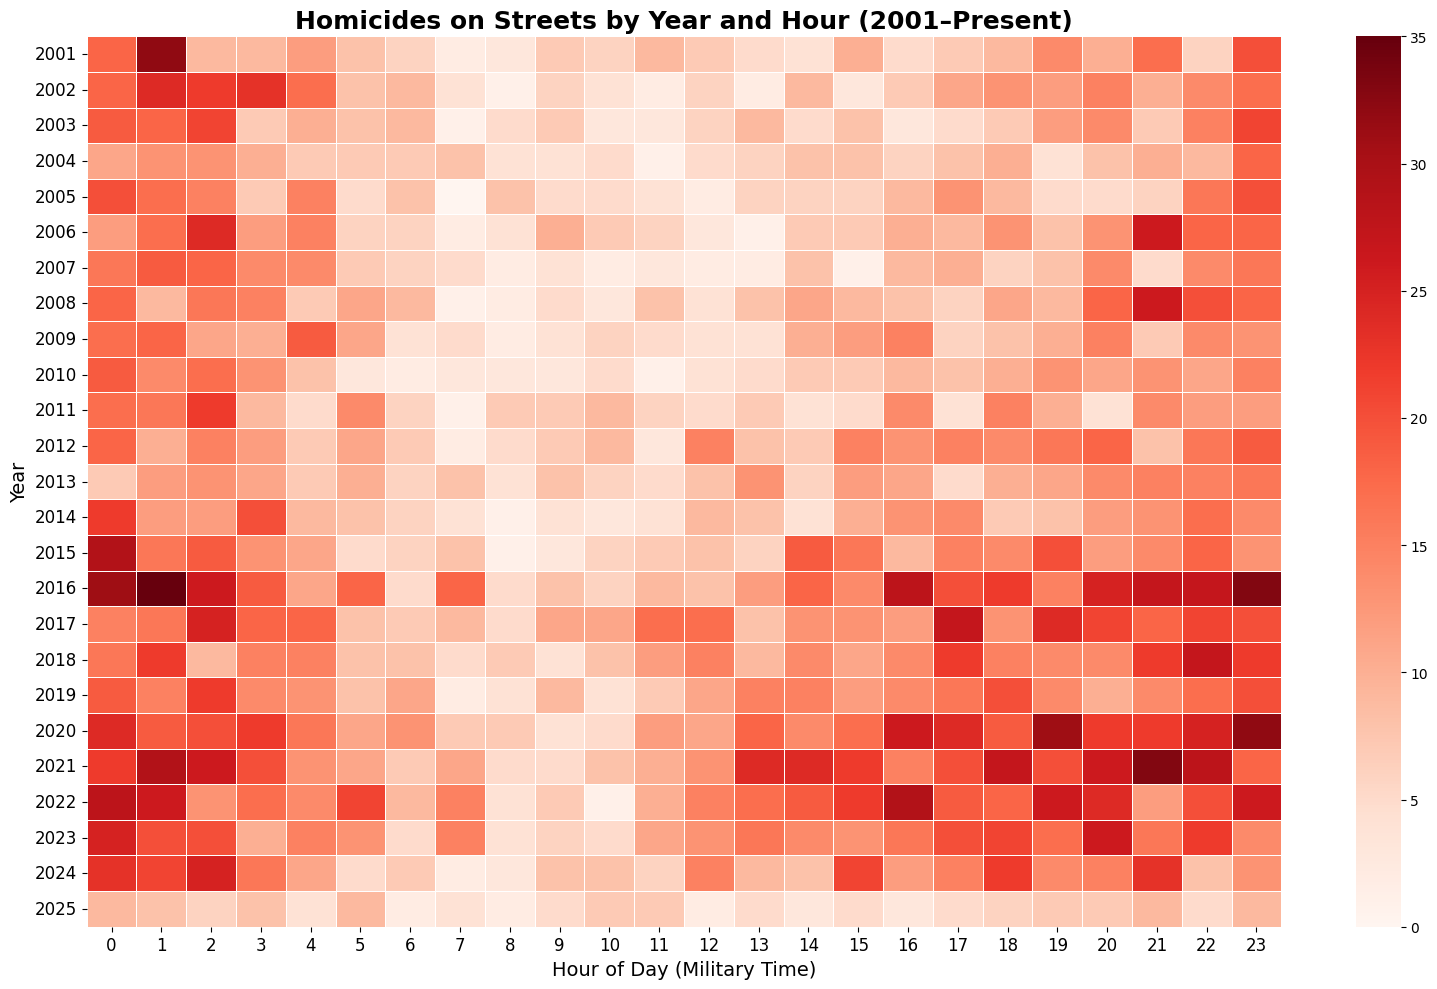

In [25]:
homicides = df[(df['Year'] >= 2001) & 
               (df['Primary Type'] == 'HOMICIDE')]

homicides['Hour'] = pd.to_datetime(homicides['Date']).dt.hour

homicides_street = homicides[homicides['Location Description'] == 'STREET']

heatmap_data = homicides_street.groupby(['Year','Hour']).size().unstack(fill_value=0)

plt.figure(figsize=(16,10))
sns.heatmap(heatmap_data, cmap='Reds', linewidths=0.5)

plt.title("Homicides on Streets by Year and Hour (2001–Present)", fontsize=18, weight='bold')
plt.xlabel("Hour of Day (Military Time)", fontsize=14)
plt.ylabel("Year", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

<h2>Insights: This heatmap graph shows that cases of homicides every day according to the legend dark red means most case in an that hour and from this data we can see a several dark red shades like 2016 1 AM and 11 PM 2016 too these things may have connections because it is consistent according to this graph.</h2>

<h2>15. What is statistically significant seasonal trend in overall crime rates, and which specific crime types often happens?</h2>
<h2>VISUALIZATION #15</h2>

Monthly Crime Counts by Type:
 Month  Primary Type   
1      ASSAULT             39788
       BATTERY            110832
       CRIMINAL DAMAGE     68859
       NARCOTICS           67832
       THEFT              136462
2      ASSAULT             38075
       BATTERY            102909
       CRIMINAL DAMAGE     61088
       NARCOTICS           65766
       THEFT              117060
3      ASSAULT             47112
       BATTERY            128553
       CRIMINAL DAMAGE     78831
       NARCOTICS           70865
       THEFT              137241
4      ASSAULT             47743
       BATTERY            129422
       CRIMINAL DAMAGE     82042
       NARCOTICS           64453
       THEFT              139053
5      ASSAULT             54736
       BATTERY            147862
       CRIMINAL DAMAGE     86852
       NARCOTICS           64649
       THEFT              152236
6      ASSAULT             53348
       BATTERY            148131
       CRIMINAL DAMAGE     86614
       NARCOTICS      

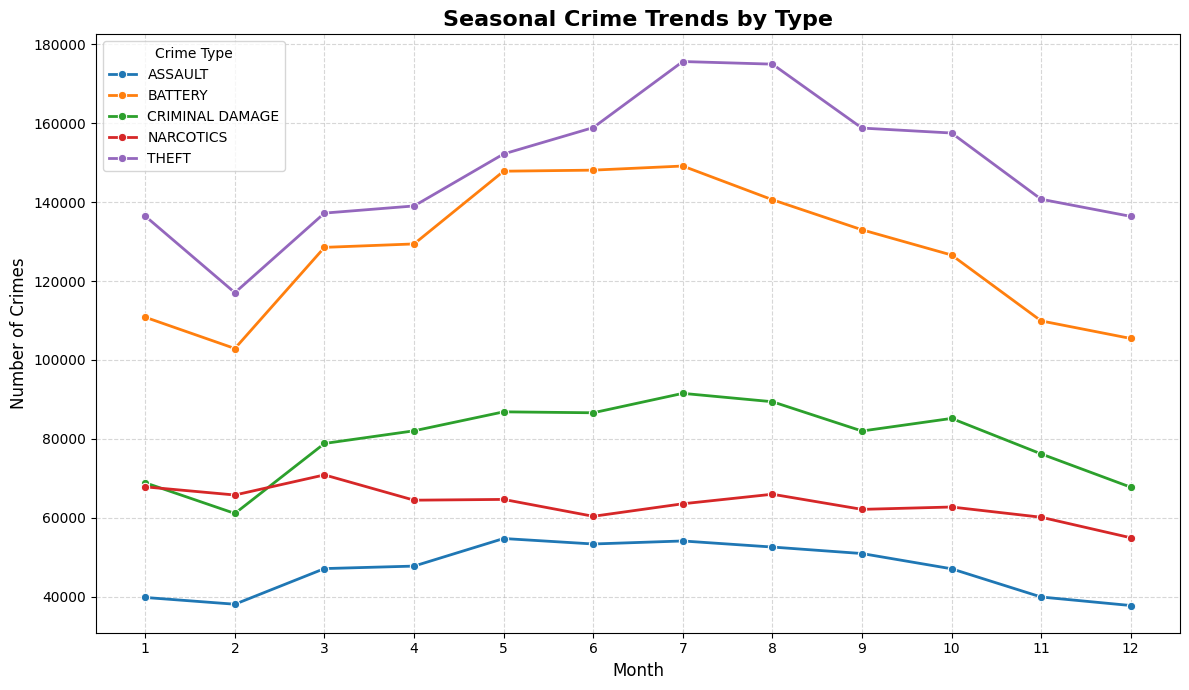

In [26]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

top_crimes = df['Primary Type'].value_counts().head(5).index
df_top = df[df['Primary Type'].isin(top_crimes)]

month_type_counts = df_top.groupby(['Month','Primary Type']).size().sort_index()
print("Monthly Crime Counts by Type:\n", month_type_counts)

monthly_by_type = month_type_counts.reset_index(name='Count')

plt.figure(figsize=(12,7))
sns.lineplot(data=monthly_by_type, x='Month', y='Count', hue='Primary Type', marker='o', linewidth=2)
plt.title("Seasonal Crime Trends by Type", fontsize=16, weight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)
plt.xticks(range(1,13))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Crime Type")
plt.tight_layout()
plt.show()

<h2>Insights: According to this graph crime rates show a clear seasonal pattern, with the highest activity in late spring and summer (May(5)–August(8)) and the lowest in winter months (December(12)–February(2)). Violent and property crimes, particularly BATTERY, THEFT, CRIMINAL DAMAGE, and ASSAULT, drive these peaks, likely due to increased outdoor activity, social gatherings, and longer daylight hours. </h2>

<h1>16. What percentage of crimes result in an arrest?</h1>
<h2>VISUALIZATION #16</h2>

Percentage of crimes resulting in an arrest: 25.24%

Arrest Counts:
 Arrest
False    6287066
True     2123132
Name: count, dtype: int64


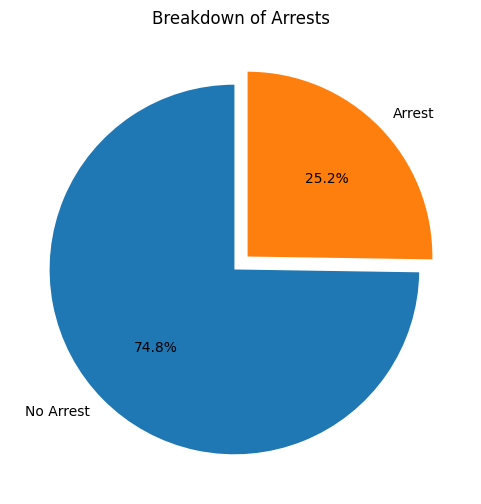

In [27]:
arrest_percentage = df['Arrest'].mean() * 100
print(f"Percentage of crimes resulting in an arrest: {arrest_percentage:.2f}%")

arrest_counts = df['Arrest'].value_counts()
print("\nArrest Counts:\n", arrest_counts)

plt.figure(figsize=(6,6))
plt.pie(arrest_counts, labels=['No Arrest','Arrest'], autopct='%1.1f%%', startangle=90, explode=(0.05,0.05))
plt.title("Breakdown of Arrests")
plt.show()

<h2>Insights: Only about 25.24% of crimes result in an arrest, meaning that 75% of criminal incidents do not lead to apprehension. No arrest 6,287,066 cases and arrest 2,123,132 cases. This means that the majority of crimes either go unsolved, are minor, or lack sufficient evidence for immediate arrest.</h2>

<h1>17. Which day of the week experiences the most crime incidents?</h1>
<h2>VISUALIZATION #17</h2>

Crimes by Day of the Week:
 DayOfWeek
Friday       1261341
Wednesday    1208169
Saturday     1206357
Tuesday      1200628
Thursday     1196290
Monday       1189517
Sunday       1147896
Name: count, dtype: int64

Day with most crimes: Friday


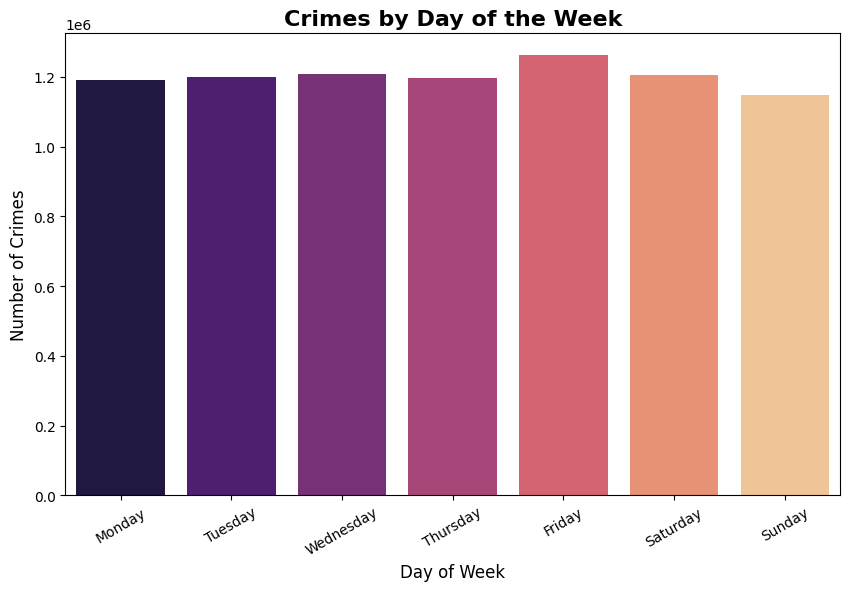

In [28]:
df['DayOfWeek'] = pd.to_datetime(df['Date']).dt.day_name()

dow_counts = df['DayOfWeek'].value_counts()
print("Crimes by Day of the Week:\n", dow_counts)

most_crime_day = dow_counts.idxmax()
print(f"\nDay with most crimes: {most_crime_day}")

# Plot bar chart
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.reindex(weekday_order)

plt.figure(figsize=(10,6))
sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='magma')
plt.title("Crimes by Day of the Week", fontsize=16, weight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)
plt.xticks(rotation=30)
plt.show()

<h2>Insights: The data indicates that Wednesday to Friday slightly increase criminal activity, maybe because of increased social interactions during weekdays leading up to the weekend and more public activity in commercial or entertainment areas. </h2>

<h1>18. Is there a correlation between the hour of day and arrest rates—are crimes at certain times more likely to result in arrests?</h1
                                                                                                                                        

<h2>VISUALIZATION #18</h2>

Arrest rate by hour (%):
 Hour
0     18.358557
1     24.601799
2     23.141141
3     21.490386
4     19.465871
5     16.162214
6     17.767652
7     16.569245
8     17.415482
9     17.605832
10    24.803900
11    30.647400
12    24.503743
13    28.543829
14    26.373613
15    24.425665
16    24.769333
17    23.572522
18    25.650851
19    31.289925
20    31.627806
21    31.435929
22    29.581133
23    29.470701
Name: Arrest, dtype: float64


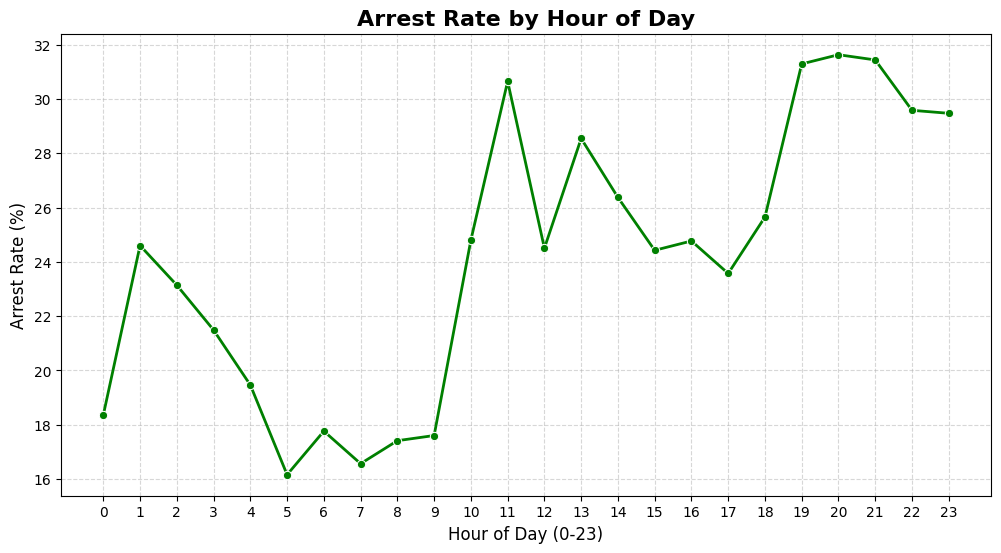

In [29]:
df['Hour'] = pd.to_datetime(df['Date']).dt.hour

arrest_rate_by_hour = df.groupby('Hour')['Arrest'].mean() * 100  # convert to percentage
print("Arrest rate by hour (%):\n", arrest_rate_by_hour)

plt.figure(figsize=(12,6))
sns.lineplot(x=arrest_rate_by_hour.index, y=arrest_rate_by_hour.values, marker='o', color='green', linewidth=2)
plt.title("Arrest Rate by Hour of Day", fontsize=16, weight='bold')
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Arrest Rate (%)", fontsize=12)
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<h2>Insights: It shows that in the graph arrest rates show a strong correlation with the time of day. Crimes committed in the evening and late night (19:00–21:00) have the highest likelihood of resulting in an arrest, maybe because at this time police likes to patrol , high public visibility, and immediate detection of offenses. But crimes occurring in the early morning (5:00–7:00)has the less percentage of arrest because of lower patrol activity, fewer witnesses, and crimes in less monitored locations. </h2>

<h1>19. Is there a correlation between domestic incidents and arrest likelihood?</h1>

<h2>VISUALIZATION #19</h2>

Arrest rate for Domestic vs Non-Domestic incidents:
 Domestic
False    0.264957
True     0.192481
Name: Arrest, dtype: float64

Correlation between Domestic flag and Arrest: -0.06


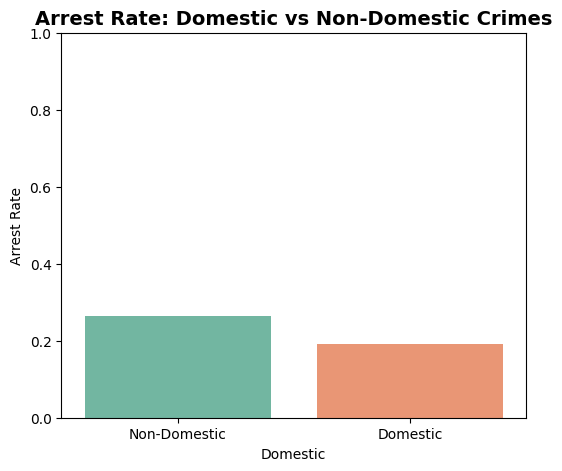

In [30]:
arrest_domestic = df.groupby('Domestic')['Arrest'].mean()
print("Arrest rate for Domestic vs Non-Domestic incidents:\n", arrest_domestic)

correlation = df['Domestic'].astype(int).corr(df['Arrest'].astype(int))
print(f"\nCorrelation between Domestic flag and Arrest: {correlation:.2f}")

plt.figure(figsize=(6,5))
sns.barplot(x=arrest_domestic.index, y=arrest_domestic.values, palette='Set2')
plt.xticks([0,1], ['Non-Domestic', 'Domestic'])
plt.ylabel("Arrest Rate")
plt.title("Arrest Rate: Domestic vs Non-Domestic Crimes", fontsize=14, weight='bold')
plt.ylim(0,1)
plt.show()

<h2>Insights: Domestic incidents are less likely to result in arrests compared to non-domestic crimes, with an arrest . This means that domestic crimes often involve misunderstanding, underreporting, or no solid evidence, so it means that their goverment needs an another approach to fix this issues. </h2>

<h1>20. Do weekends have higher crime rates than weekdays?</h1>

<h2>VISUALIZATION #20</h2>

Crimes by Day Type:
 DayType
Weekday    6055945
Weekend    2354253
Name: count, dtype: int64


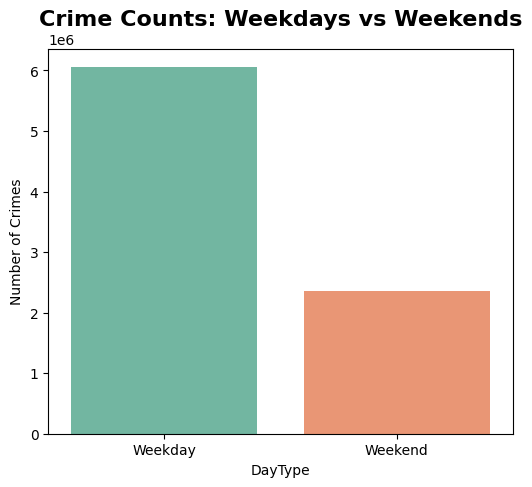

In [31]:

df['DayOfWeek'] = pd.to_datetime(df['Date']).dt.day_name()

weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday']
df['DayType'] = df['DayOfWeek'].apply(lambda x: 'Weekday' if x in weekdays else 'Weekend')

daytype_counts = df['DayType'].value_counts()
print("Crimes by Day Type:\n", daytype_counts)

plt.figure(figsize=(6,5))
sns.barplot(x=daytype_counts.index, y=daytype_counts.values, palette='Set2')
plt.title("Crime Counts: Weekdays vs Weekends", fontsize=16, weight='bold')
plt.ylabel("Number of Crimes")
plt.show()

<h2>Insights: According to the result weekdays experience has more crimes than weekends, with 6,055,945 incidents on weekdays versus 2,354,253 on weekends. This means that criminal activity is higher during periods of regular day. </h2>

<h2>21. Are certain months associated with higher arrest rates?</h2>
<h2>VISUALIZATION #21</h2>


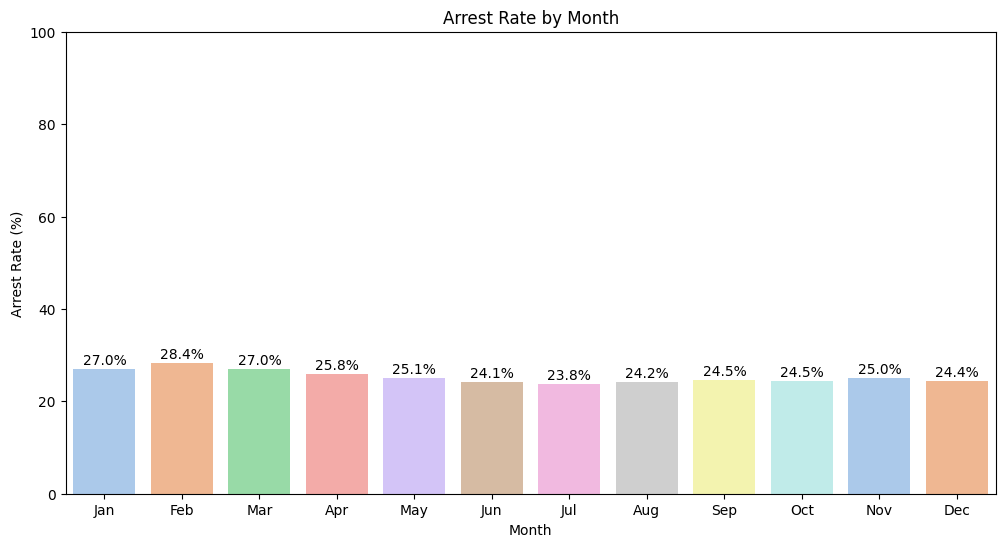

In [32]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Month'] = df['Date'].dt.month

df_valid = df.dropna(subset=['Month', 'Arrest'])

arrest_by_month = df_valid.groupby('Month')['Arrest'].mean() * 100

arrest_by_month = arrest_by_month.reindex(range(1,13), fill_value=0)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12,6))
sns.barplot(x=month_names, y=arrest_by_month.values, palette="pastel")
plt.xlabel("Month")
plt.ylabel("Arrest Rate (%)")
plt.title("Arrest Rate by Month")
plt.ylim(0, 100)

for i, v in enumerate(arrest_by_month.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

<h2>Insights: It shows here that February has the most arrest percentage (28.4%) but according to our data earlier from the question 10 it has the lowest theft recorded maybe this is what we are talking about an event that connected why in question 10 it plummeted to almost nothing. so back to the topic month May to Dec they are close each others percentages means it is stable arrest. This need to change because it means their polices can't bring justice to these crimes. </h2>

<h1>22. Is there a difference in crime patterns between morning, afternoon, evening, and night?</h1>
<h2>VISUALIZATION #22</h2>

Crimes by Time of Day:
 TimeOfDay
Morning      1706877
Afternoon    2609679
Evening      2665378
Night        1428264
Name: count, dtype: int64


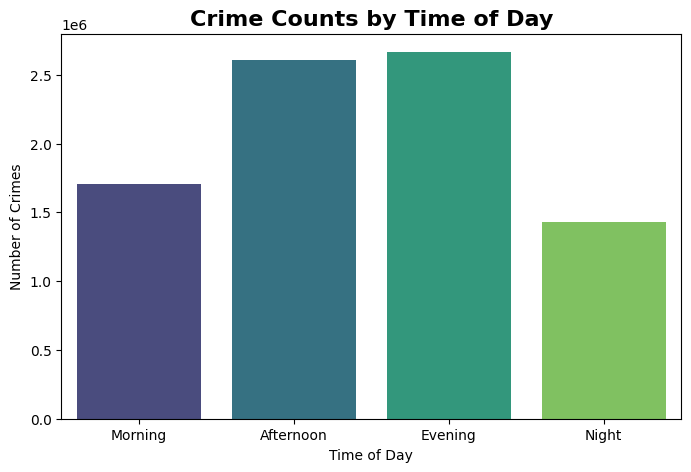

In [33]:
df['Hour'] = pd.to_datetime(df['Date']).dt.hour

def time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df['TimeOfDay'] = df['Hour'].apply(time_of_day)

tod_counts = df['TimeOfDay'].value_counts().reindex(['Morning','Afternoon','Evening','Night'])
print("Crimes by Time of Day:\n", tod_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=tod_counts.index, y=tod_counts.values, palette='viridis')
plt.title("Crime Counts by Time of Day", fontsize=16, weight='bold')
plt.xlabel("Time of Day")
plt.ylabel("Number of Crimes")
plt.show()

<h2>Insights: This graph shows that crime during the time of day. The highest number of crimes occur in the evening and afternoon reflecting periods of high public activity, social interactions, and commercial movement. Mornings see moderate crime levels, while nighttime experiences the crimes, because its likely due to reduced outdoor activity and lower street presence. </h2>

<h1>23.Which crime types dominate in each time period?</h1>
<h2>VISUALIZATION #23</h2>

Dominant Crime Type per Hour:
Hour
0       THEFT
1     BATTERY
2     BATTERY
3     BATTERY
4     BATTERY
5     BATTERY
6       THEFT
7       THEFT
8       THEFT
9       THEFT
10      THEFT
11      THEFT
12      THEFT
13      THEFT
14      THEFT
15      THEFT
16      THEFT
17      THEFT
18      THEFT
19      THEFT
20      THEFT
21    BATTERY
22    BATTERY
23    BATTERY
dtype: object


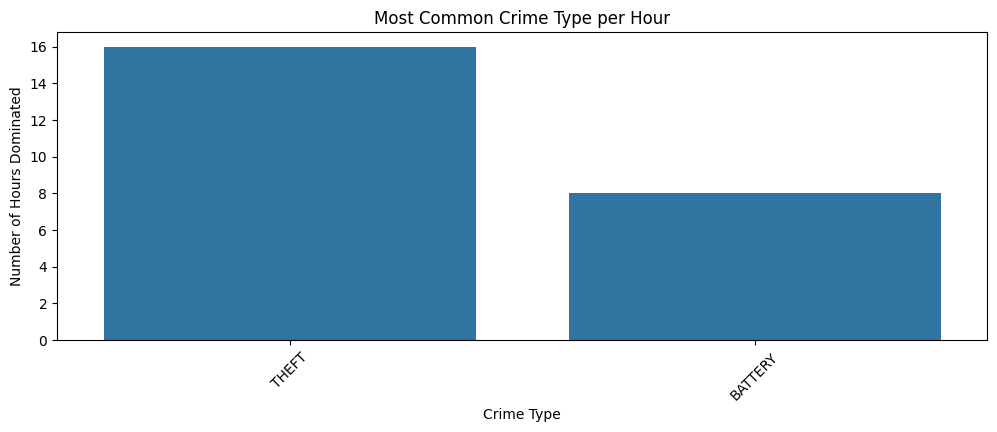

In [34]:
hourly_crimes = df.groupby(['Hour','Primary Type']).size().unstack(fill_value=0)

dominant_crimes_hour = hourly_crimes.idxmax(axis=1)
print("Dominant Crime Type per Hour:")
print(dominant_crimes_hour)

plt.figure(figsize=(12,4))
sns.countplot(x=dominant_crimes_hour)
plt.xticks(rotation=45)
plt.title("Most Common Crime Type per Hour")
plt.xlabel("Crime Type")
plt.ylabel("Number of Hours Dominated")
plt.show()

<h2>Insights: According to the data battery dominates in the morning and night, reflecting interpersonal conflicts and late-night disputes, while theft dominates in the afternoon and evening, corresponding to periods of high public and commercial activity. Base on this we can predict when crimes can happen and protect ourselves from it.</h2>

<h1>24. Which day of the week has the highest arrest rate (arrests/total crimes)?</h1>

<h2>VISUALIZATION #24</h2>

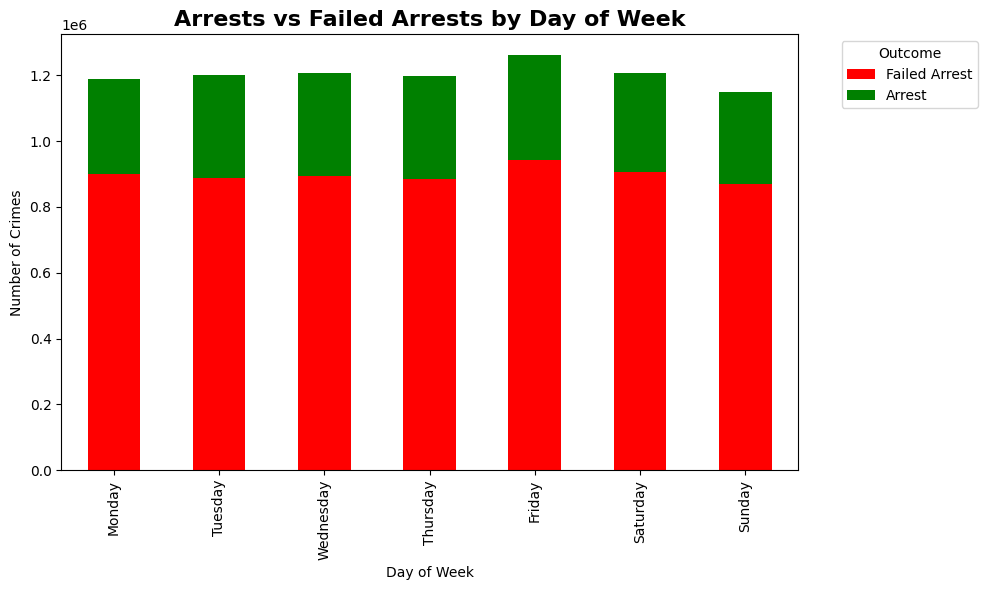

In [35]:
df['DayOfWeek'] = pd.to_datetime(df['Date']).dt.day_name()

arrest_counts = df.groupby('DayOfWeek')['Arrest'].value_counts().unstack(fill_value=0)
arrest_counts = arrest_counts.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

ax = arrest_counts.plot(kind='bar', stacked=True, figsize=(10,6), color=['red','green'])
plt.title("Arrests vs Failed Arrests by Day of Week", fontsize=16, weight='bold')
plt.xlabel("Day of Week")
plt.ylabel("Number of Crimes")

plt.legend(['Failed Arrest','Arrest'], title="Outcome", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

<h1>Insights: According to the data shown the green is the successfull arrest and the red are the failed arrest here we can see how weak our justice system only a quarter of crimes committed given the justice they want and the left are still roaming free like nothing happend. </h1>

<h1>25.Which crime types have the highest arrest rates per day?</h1

<h2>VISUALIZATION #25</h2>

Top 10 Crime Types by Arrest Rate (%):
Primary Type
DOMESTIC VIOLENCE                    100.000000
PROSTITUTION                          99.558270
NARCOTICS                             99.346820
GAMBLING                              99.270272
LIQUOR LAW VIOLATION                  99.011511
PUBLIC INDECENCY                      98.139535
CONCEALED CARRY LICENSE VIOLATION     96.570729
INTERFERENCE WITH PUBLIC OFFICER      91.633624
OBSCENITY                             73.894737
WEAPONS VIOLATION                     72.596717
Name: Arrest, dtype: float64


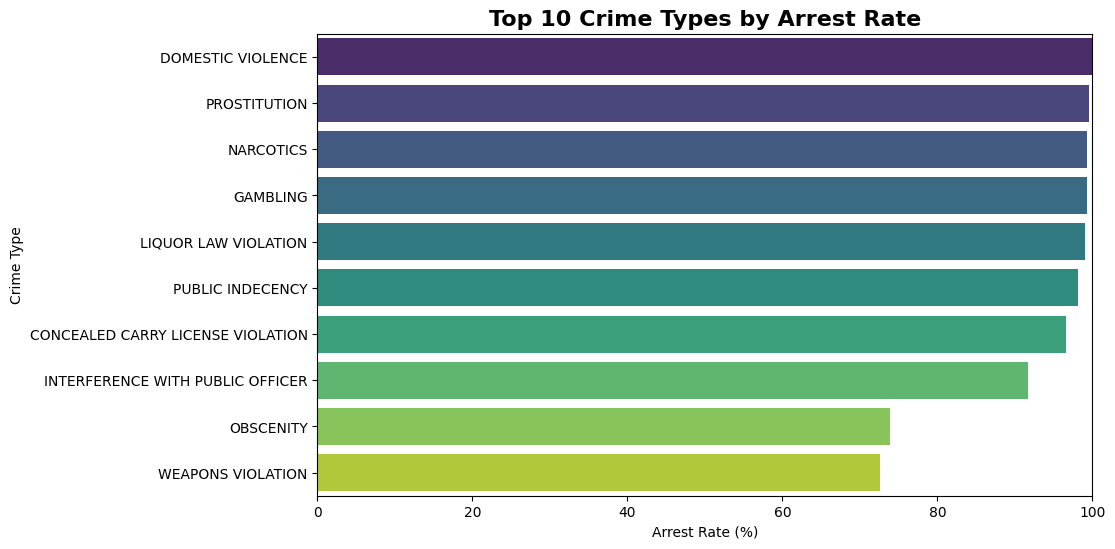

In [36]:
df['Arrest'] = df['Arrest'].astype(bool)

crime_arrest_rate = df.groupby('Primary Type')['Arrest'].mean() * 100

top_crimes = crime_arrest_rate.sort_values(ascending=False).head(10)
print("Top 10 Crime Types by Arrest Rate (%):")
print(top_crimes)

plt.figure(figsize=(10,6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette='viridis')
plt.title("Top 10 Crime Types by Arrest Rate", fontsize=16, weight='bold')
plt.xlabel("Arrest Rate (%)")
plt.ylabel("Crime Type")
plt.xlim(0,100)
plt.show()

<h2>Insights: This data shows that these crimes are highly enforceable, because occurring in contexts this is where police can intervene directly, or they involve clear legal violations that require immediate action. But unlike the top crimes the percentages are so low compare to this.

<h1>26. Which location types (Street, Residence, Apartment, etc.) have the most crimes?</h1>

<h2>VISUALIZATION #26</h2>

Top 10 Location Types by Crime Count:
 Location Description
STREET                            2197287
RESIDENCE                         1381812
APARTMENT                          998492
SIDEWALK                           761765
OTHER                              269939
PARKING LOT/GARAGE(NON.RESID.)     202930
ALLEY                              187348
SMALL RETAIL STORE                 168926
SCHOOL, PUBLIC, BUILDING           146368
RESTAURANT                         141262
Name: count, dtype: int64


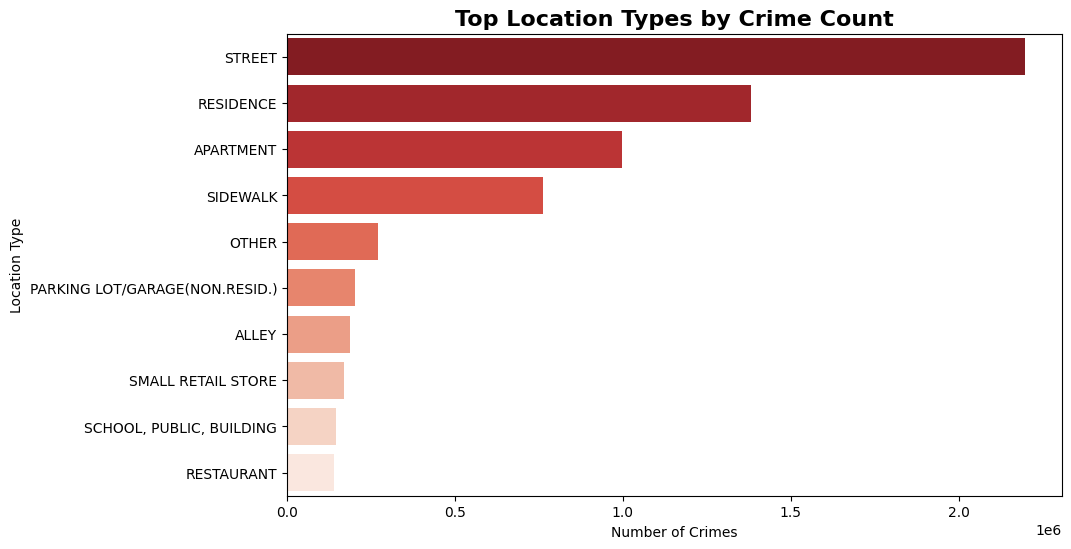

In [37]:
location_counts = df['Location Description'].value_counts()
top_locations = location_counts.head(10)
print("Top 10 Location Types by Crime Count:\n", top_locations)

plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='Reds_r')
plt.title("Top Location Types by Crime Count", fontsize=16, weight='bold')
plt.xlabel("Number of Crimes")
plt.ylabel("Location Type")
plt.show()

<h2>Insights: According to this data it shows that the top locations is the street. According from the data I shown earlier street compose differents crimes but it mostly covered by battery,theft and homicide these 3 alone covered the half of it. It just means that streets of chicago is a very dangerous place to roam around at a certain time according from the previous records.</h2>

<h1>27. Street Homicides per Year</h1>

<h2>VISUALIZATION #27</h2>

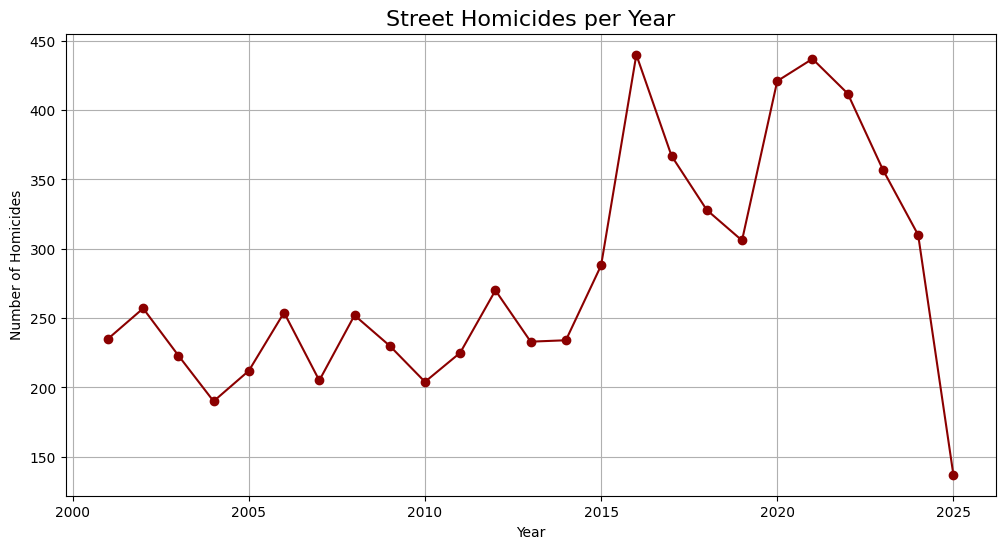

In [38]:
street_homicides = df[(df['Primary Type'] == 'HOMICIDE') & 
                      (df['Location Description'].str.upper() == 'STREET')]

homicide_by_year_hour = street_homicides.groupby(['Year', 'Hour']).size().reset_index(name='Count')

yearly_counts = street_homicides.groupby('Year').size()
plt.figure(figsize=(12,6))
yearly_counts.plot(kind='line', marker='o', color='darkred')
plt.title("Street Homicides per Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Number of Homicides")
plt.grid(True)
plt.show()

<h2>Insights: According to this data it chicago street homicides from the year 2000 to 2025, chicago reaches its peak at 2016 araound 440 then it declines in 2019 covid times, then struck again maybe when covid was lifted then it declines maybe due to events, or because criminals realize that at this time there are too many cameras set up around now. </h2>

<h1>28. Number of Domestic Crimes by Month</h1>

<h2>VISUALIZATION #28</h2>

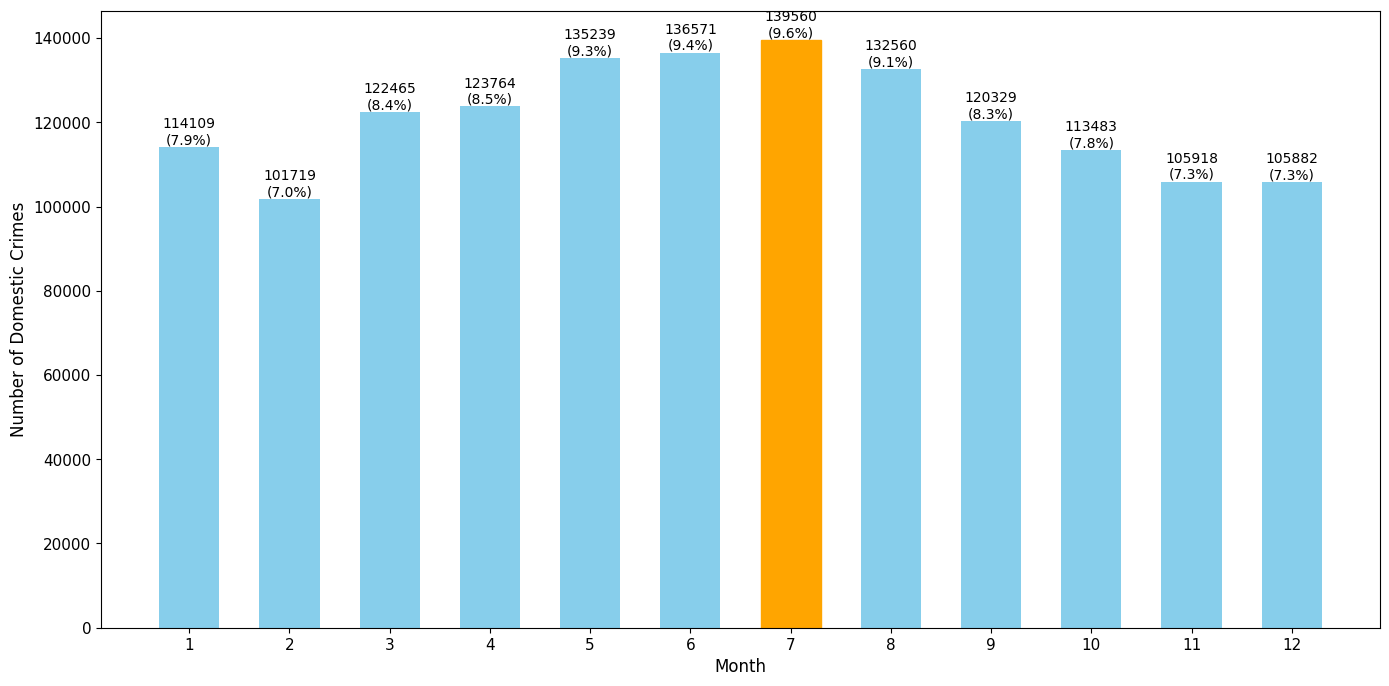

In [39]:
domestic_df = df[df['Domestic'] == True]

monthly_domestic = domestic_df.groupby(domestic_df['Date'].dt.month).size()
monthly_percentage = (monthly_domestic / monthly_domestic.sum()) * 100

plt.figure(figsize=(14,7))
bars = plt.bar(range(1,13), monthly_domestic, color='skyblue', width=0.6)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Domestic Crimes", fontsize=12)
plt.xticks(range(1,13), fontsize=11)
plt.yticks(fontsize=11)

for bar, count, pct in zip(bars, monthly_domestic, monthly_percentage):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f"{count}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

peak_month = monthly_domestic.idxmax()
bars[peak_month-1].set_color('orange')

plt.tight_layout()
plt.show()

<h2>Insights: According to the data, the orange-colored bar represents the highest domestic crime percentage by the month , the month of july has the 9.6% of domestic crime this kind of should not be tolerated.</h2>

<h1>29. Domestic Crimes by Day of Week</h1>

<h2>VISUALIZATION #29</h2>

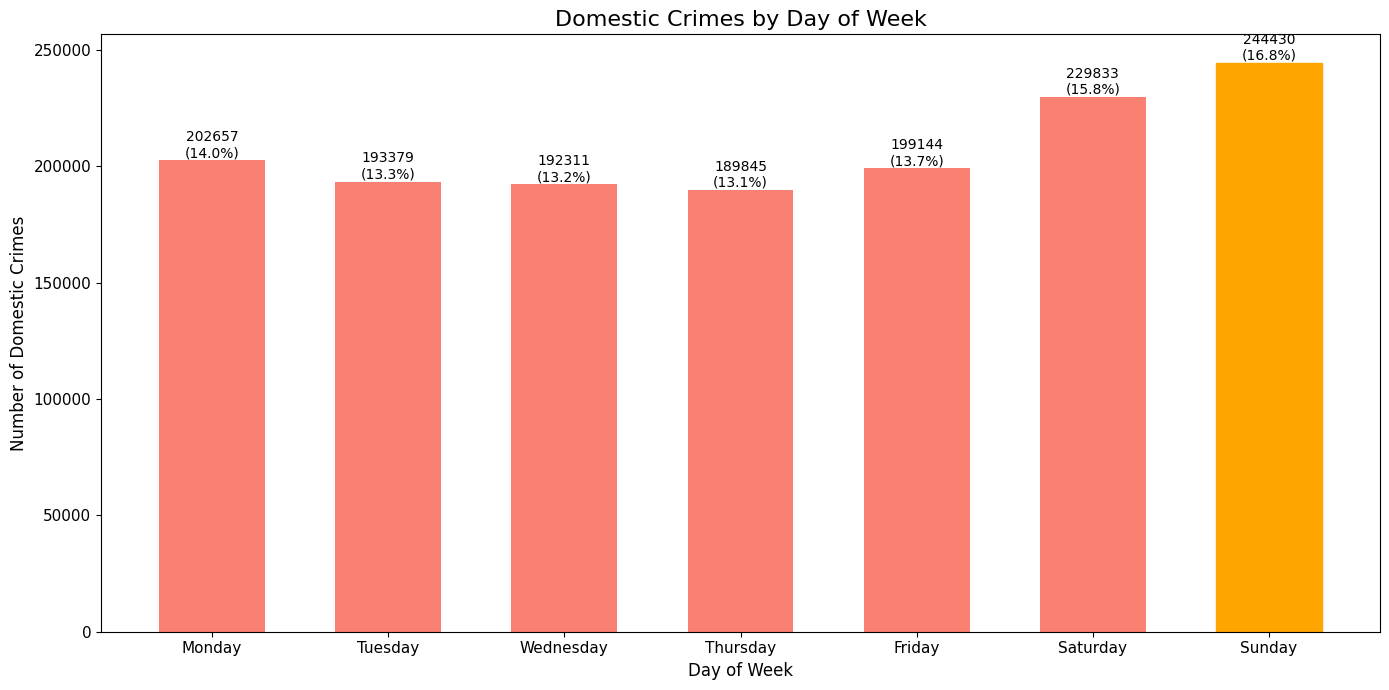

In [40]:
domestic_df['DayOfWeek'] = domestic_df['Date'].dt.day_name()
dow_domestic = domestic_df.groupby('DayOfWeek').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
dow_percentage = (dow_domestic / dow_domestic.sum()) * 100

plt.figure(figsize=(14,7))
bars = plt.bar(dow_domestic.index, dow_domestic, color='salmon', width=0.6)
plt.title("Domestic Crimes by Day of Week", fontsize=16)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Number of Domestic Crimes", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

for bar, count, pct in zip(bars, dow_domestic, dow_percentage):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{count}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

peak_day = dow_domestic.idxmax()
bars[list(dow_domestic.index).index(peak_day)].set_color('orange')

plt.tight_layout()
plt.show()

<h2>Insights: On this data it shows that the day that have the highest percent is sunday maybe this can be related to alcohol or stress of monday that person didn't have enough rest. But I am pretty sure this is influenced by alcohol thats why it reach this peak. </h2>

<h1>30. Domestic Crimes by Hour</h1>

<h2>VISUALIZATION #30</h2>

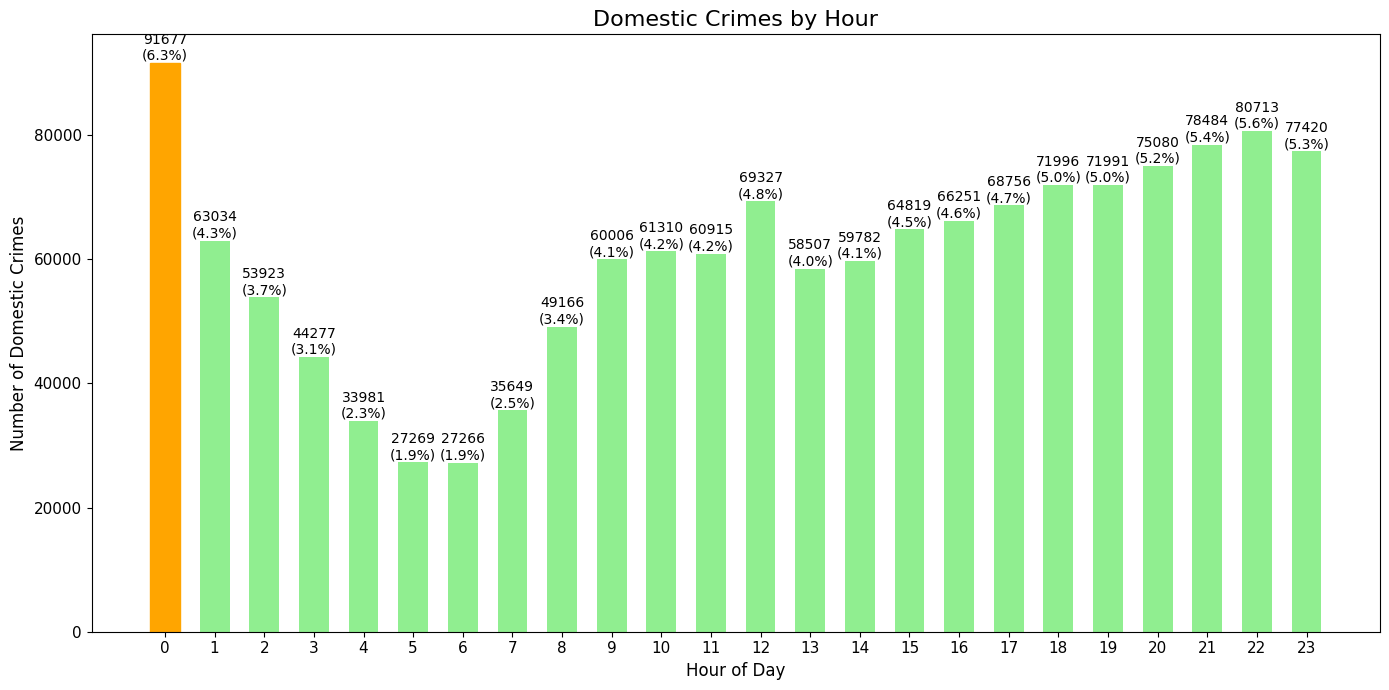

In [41]:
domestic_df['Hour'] = domestic_df['Date'].dt.hour
hour_domestic = domestic_df.groupby('Hour').size()
hour_percentage = (hour_domestic / hour_domestic.sum()) * 100

plt.figure(figsize=(14,7))
bars = plt.bar(hour_domestic.index, hour_domestic, color='lightgreen', width=0.6)
plt.title("Domestic Crimes by Hour", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Domestic Crimes", fontsize=12)
plt.xticks(hour_domestic.index, fontsize=11)
plt.yticks(fontsize=11)

for bar, count, pct in zip(bars, hour_domestic, hour_percentage):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{count}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

peak_hour = hour_domestic.idxmax()
bars[peak_hour].set_color('orange')

plt.tight_layout()
plt.show()

<h2>Insights: Based on the graph, domestic crimes peak around midnight. The increase in incidents starting from 8 PM suggests a clear pattern, likely influenced by alcohol consumption and late-night conflicts. This hourly trend indicates that domestic violence is time-sensitive, with higher risks during late evening and nighttime hours, highlighting the need for targeted interventions, awareness campaigns, and timely law enforcement response during these high-risk periods.  </h2>

<h1>31. Which FBI crime codes are most common?  </h1>


<h2>VISUALIZATION #31</h2>

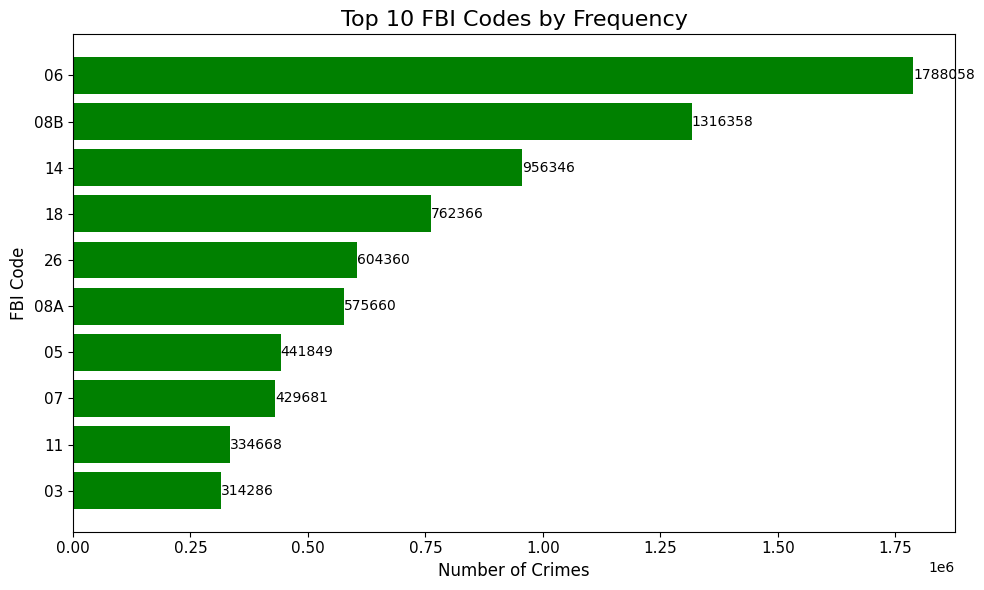

In [42]:
top_fbi = df['FBI Code'].value_counts().head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top_fbi.index.astype(str), top_fbi.values, color='green')
plt.title("Top 10 FBI Codes by Frequency", fontsize=16)
plt.xlabel("Number of Crimes", fontsize=12)
plt.ylabel("FBI Code", fontsize=12)
plt.gca().invert_yaxis()
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

<h2>Insights: The most frequent FBI codes are associated with theft and assault , confirming that these two crime types dominate the city’s crime profile according from the data I used earlier. </h2>

<h1>32. Which FBI codes usually appears in domestic crimes? </h1>

<h2>VISUALIZATION #32</h2>

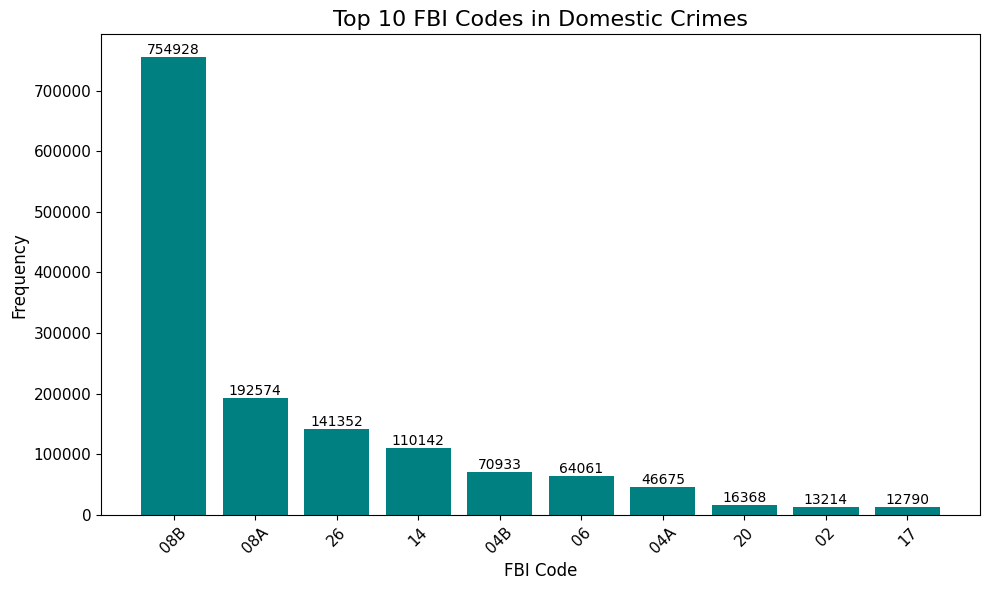

In [43]:
top_domestic_fbi = df[df['Domestic'] == True]['FBI Code'].value_counts().head(10)

plt.figure(figsize=(10,6))
bars = plt.bar(top_domestic_fbi.index.astype(str), top_domestic_fbi.values, color='teal')
plt.title("Top 10 FBI Codes in Domestic Crimes", fontsize=16)
plt.xlabel("FBI Code", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


<h2>Insights: According to the result FBI code 08B usually handle this cases than the other codes this means this is their field and they are professional at handling this cases.</h2>

<h1>33. Which FBI codes appear most often in domestic crimes? </h1>

<h2>VISUALIZATION #33</h2>

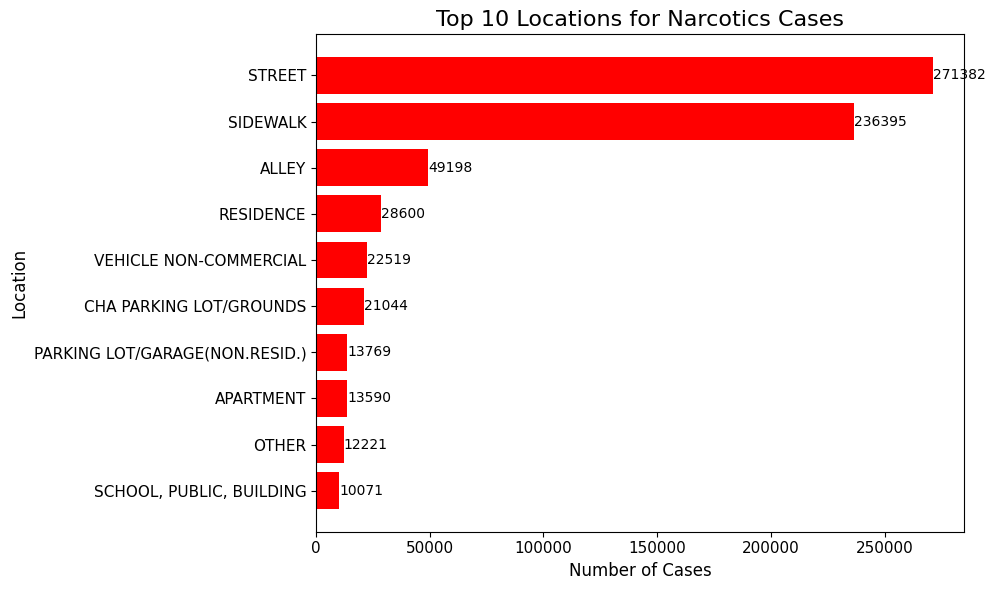

In [44]:
top_narcotics_locations = df[df['Primary Type'] == "NARCOTICS"]['Location Description'].value_counts().head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top_narcotics_locations.index.astype(str), top_narcotics_locations.values, color='red')
plt.title("Top 10 Locations for Narcotics Cases", fontsize=16)
plt.xlabel("Number of Cases", fontsize=12)
plt.ylabel("Location", fontsize=12)
plt.gca().invert_yaxis()
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add value labels
for bar in bars:
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

<h2>Insights: According here Narcotis cases mostly appear in streets just like the battery and theft this means most of the crime happens on the streets where people walk by.  </h2>

<h1>34. What is the highest and lowest case of narcotics per year?</h1>

<h2>VISUALIZATION #34</h2>

Lowest year: 2022 (4757 cases)
Highest year: 2004 (57060 cases)


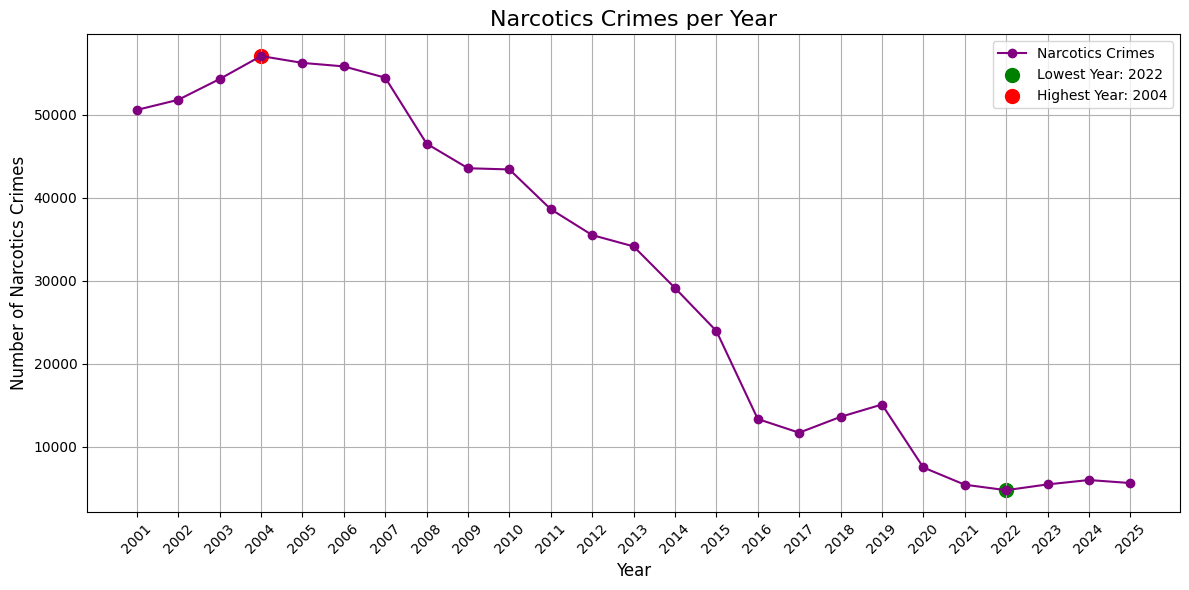

In [45]:
narcotics_df = df[df['Primary Type'] == "NARCOTICS"]

narcotics_per_year = narcotics_df.groupby('Year').size()

lowest_year = narcotics_per_year.idxmin()
highest_year = narcotics_per_year.idxmax()
lowest_count = narcotics_per_year.min()
highest_count = narcotics_per_year.max()

print(f"Lowest year: {lowest_year} ({lowest_count} cases)")
print(f"Highest year: {highest_year} ({highest_count} cases)")

plt.figure(figsize=(12,6))
plt.plot(narcotics_per_year.index, narcotics_per_year.values, marker='o', color='purple', label='Narcotics Crimes')

plt.scatter(lowest_year, lowest_count, color='green', s=100, label=f'Lowest Year: {lowest_year}')
plt.scatter(highest_year, highest_count, color='red', s=100, label=f'Highest Year: {highest_year}')

plt.title("Narcotics Crimes per Year", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Narcotics Crimes", fontsize=12)
plt.xticks(narcotics_per_year.index, rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<h2>Insights: It shows that narcotics related crimes show a dramatic decline over the years, with the highest number of cases in 2004 (57,060) and the lowest in 2022 (4,757). This means that reduction in reported narcotics offenses, maybe this happend because they made a good counter measure or maybe the criminals made an another way of transactions.</h2>

<h1>35. Which crimes most often lead to arrests?</h1>

<h2>VISUALIZATION #35</h2>

<function matplotlib.pyplot.show(close=None, block=None)>

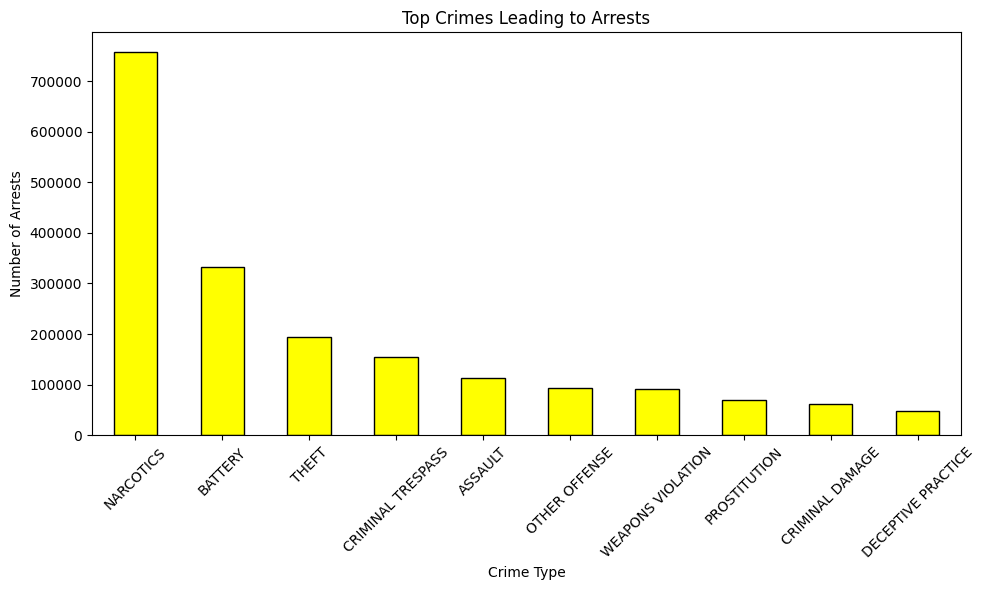

In [46]:

arrest_counts = df[df['Arrest'] == True]['Primary Type'].value_counts().head(10)

plt.figure(figsize=(10,6))
arrest_counts.plot(kind='bar', color='yellow', edgecolor='black')

plt.title('Top Crimes Leading to Arrests')
plt.xlabel('Crime Type')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

<h2>Insights According to this graph arrests are frequent in narcotics because most of them gets set up and mostly gets suspects as a user by the police and during the checking they got that illegal goods from them. And some of them are the betrayals of each other that leads to arrest.</h2>